# Machine Learning - Spring 2026
## Homework 2

Instructor: Dr. Ilia Tetin


Student ID: 11461313A

Student Name: Christopher D. Pagaduan

In [3]:
import shutil, sys

# Copy .py files from input to working directory so they can be imported
shutil.copy('/kaggle/input/datasets/christopherpagaduan/datas-py/descents.py', '/kaggle/working/descents.py')
shutil.copy('/kaggle/input/datasets/christopherpagaduan/datas-py/linear_regression.py', '/kaggle/working/linear_regression.py')

# Make sure working directory is in the import path
sys.path.insert(0, '/kaggle/working')

In [4]:
import numpy as np
import sklearn
from linear_regression import MSELoss, CustomLinearRegression
from descents import AnalyticSolutionOptimizer
from sklearn.metrics import mean_squared_error as mse

### About the assignment

In this task, you will implement the training of a linear regression model using several variants of gradient-based optimization. In `descents.py`, you are expected to complete a set of classes corresponding to different optimization strategies:

* `VanillaGradientDescent`
* `StochasticGradientDescent`
* `SAGDescent`
* `MomentumDescent`
* `Adam`

In `linear_regression.py`, you will need to implement the `CustomLinearRegression` class, which will handle both fitting the linear regression model and generating predictions for the target variable based on the learned parameters.

### About the proposed architecture

The provided template structure follows SOLID-style design principles. Its main advantage is that you can combine different loss functions and optimizers without rewriting the surrounding logic of the other classes. This is achieved by separating responsibilities clearly and relying on interfaces rather than hard-coded implementations. In Python, these interfaces are represented through abstract base classes.

At a high level, the architecture consists of four main interfaces (some of which are also represented directly by concrete base classes), each defining its own family of components:

* `interfaces.LossFunction`
  Classes implementing this interface are responsible for a specific loss function used during training, along with all behavior tied to that choice: loss computation, gradient calculation, and, when applicable, an analytical solution provided through an appropriate mixin.

* `interfaces.LinearRegressionInterface`
  This is the wrapper interface for the linear regression model itself. It acts as a container that combines the main components (the loss function and the optimizer) and uses them to perform the actual training and prediction workflow.

* `interfaces.LearningRateSchedule`
  A small family of schedules that determine the learning rate at each optimization step.

* `interfaces.AbstractOptimizer`
  Classes implementing this interface define a particular optimization algorithm and everything related to its execution. They interact with the linear regression wrapper to access the data and trigger the necessary computations, which keeps them independent of any specific loss function or learning-rate schedule.

The idea of passing small, self-contained objects into a more complex object so that each one handles its own narrow responsibility is known as **dependency injection**. This works effectively because each component is built around a well-defined interface rather than a specific implementation.

Take a look at `linear_regression.CustomLinearRegression`: it accepts objects implementing the `LossFunction` and `AbstractOptimizer` interfaces. In turn, `descents.BaseDescent`, which refines the abstract optimizer into an iterative optimization base class, receives a learning-rate scheduler during initialization.

Because of this structure, client code can proceed step by step:

* create the desired learning-rate scheduler with the required parameters;
* create the optimizer, passing in its configuration together with the scheduler;
* create the linear regression model with the appropriate loss function and the prepared optimizer;
* start the training process.

At each stage, one component can be replaced with another compatible implementation, and the rest of the system will continue to work seamlessly.

**As you work through this assignment, you will extend all of these class families with multiple implementations and swap them in and out with ease.**

For a more detailed overview of class inheritance in Python, see:

* Inheritance: `https://docs.python.org/3/tutorial/classes.html#inheritance`
* Abstract classes: `https://docs.python.org/3/library/abc.html`


### Gradient of the MSE Loss Function

In the seminar on matrix and vector differentiation, you were expected to discuss how to differentiate the MSE loss in matrix form.

### Task 1.0. MSE Gradient in Matrix Form (0.3 points)

Recall that the MSE loss can be written as

$$
Q(w) = \frac{1}{\ell} \sum_{i=1}^{\ell} (y_i - \langle x_i, w \rangle)^2
= \frac{1}{\ell} |Xw - y|^2
$$

where $\ell$ is the number of training samples, $X \in \mathbb{R}^{\ell \times d}$ is the feature matrix, and $y \in \mathbb{R}^{\ell}$ is the target vector. The notation $x_i$ refers to the $i$-th row of $X$, corresponding to the $i$-th sample.

* **Write down the gradient of the MSE loss in matrix form** (either from the seminar notes or by deriving it yourself).

**Solution:**

`### write your solution here ###`

* **Implement the methods `MSELoss.loss` and `MSELoss.gradient`**

**Solution:**

We want to find the gradient of:

$$Q(w) = \frac{1}{\ell} \|Xw - y\|^2 = \frac{1}{\ell}(Xw - y)^\top(Xw - y)$$

**Step 1 — Expand:**

$$Q(w) = \frac{1}{\ell}\left[ w^\top X^\top X w - 2w^\top X^\top y + y^\top y \right]$$

**Step 2 — Differentiate term by term:**

- $\nabla_w \left[ w^\top X^\top X w \right] = 2X^\top X w$
- $\nabla_w \left[ -2w^\top X^\top y \right] = -2X^\top y$
- $\nabla_w \left[ y^\top y \right] = 0$

**Step 3 — Final result:**

$$\boxed{\nabla_w Q(w) = \frac{2}{\ell} X^\top (Xw - y)}$$


### Task 1.1. Closed-Form Solution and `CustomLinearRegression` (0.7 points)

Before moving on to iterative optimization methods, let us recall that for some loss functions an analytical solution also exists. First, let us revisit what that solution looks like for MSE.

* **Derive the formula for the optimal $w$ in the MSE minimization problem and write it below.**
* **Implement this computation in `MSELoss._plain_analytic_solution`**

$$
\text{MSE} = |Xw - y|^2
$$

$$
w =
$$

* **Question:** As we know, the analytical solution has several drawbacks. What are they?

**Answer:** `# write your answer here`

Now let us connect this solution to our linear regression class so that the overall architecture becomes clearer.

* **Complete the class `descents.AnalyticSolutionOptimizer`**
* **Complete the class `CustomLinearRegression`**

  * At this stage, you should implement all of its methods: `fit` and `predict` will be needed immediately, while `compute_gradients` and `compute_loss` will be used in the next part.

Keep in mind the separation of responsibilities between classes.

The optimizer is responsible for controlling the training procedure, while the linear regression object mainly serves as an entry point, a container for the data, and an access layer for the computations that the optimizer relies on, such as the gradient direction at the current parameter values.

At the same time, the optimizer itself should remain generic: it should not contain any logic specific to a particular loss function. Everything it needs should be accessible through `self.model`.

Similarly, the linear regression class should also remain generic and be ready to work with any loss function and any optimizer that follows the required interface. This is an example of dependency injection, and your implementation should preserve that design properly. In the same way, anything your model needs from the loss function should be obtained by calling the corresponding methods of the injected loss object.


**Derivation of the optimal w:**

$$Q(w) = \frac{1}{\ell} \|Xw - y\|^2$$

Set the gradient to zero:

$$\frac{2}{\ell} X^\top (Xw - y) = 0 \implies X^\top X w = X^\top y$$

$$\boxed{w^* = (X^\top X)^{-1} X^\top y}$$

**Answer — drawbacks of the analytical solution:**

1. **Cost** — Inverting $X^\top X$ costs $O(d^3)$, too slow for large feature dimensions.
2. **Memory** — Storing $X^\top X$ requires $O(d^2)$ space.
3. **Singularity** — If features are collinear, $X^\top X$ is not invertible.
4. **Numerical instability** — An ill-conditioned $X^\top X$ causes large numerical errors.
5. **MSE only** — No closed-form exists for other loss functions like Huber or LogCosh.

In [5]:
# ── Inside linear_regression.py ──────────────────────────────

# 1. MSELoss._plain_analytic_solution
# Solves (XᵀX)w = Xᵀy  →  w* = (XᵀX)⁻¹ Xᵀy
@staticmethod
def _plain_analytic_solution(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    return np.linalg.solve(X.T @ X, X.T @ y)


# 2. CustomLinearRegression
class CustomLinearRegression:
    def __init__(self, optimizer=None, loss_function=None,
                 tolerance=1e-6, max_iter=1000):
        self.optimizer = optimizer
        self.loss_function = loss_function if loss_function is not None else MSELoss()
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.w = None
        self.X_train = None
        self.y_train = None
        self.loss_history = []
        if optimizer is not None:
            optimizer.set_model(self)   # dependency injection

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.X_train = X
        self.y_train = y
        self.loss_history = []
        self.w = np.zeros(X.shape[1])  # initialize weights to zero
        self.optimizer.optimize()       # delegate training to optimizer

    def predict(self, X: np.ndarray) -> np.ndarray:
        return X @ self.w               # simple dot product

    def compute_loss(self, X, y):
        return self.loss_function.loss(X, y, self.w)   # delegate to loss

    def compute_gradients(self, X, y):
        return self.loss_function.gradient(X, y, self.w)  # delegate to loss


# ── Inside descents.py ───────────────────────────────────────

# 3. AnalyticSolutionOptimizer
class AnalyticSolutionOptimizer:
    def __init__(self):
        self.model = None

    def set_model(self, model):
        self.model = model              # receives the LinearRegression object

    def optimize(self):
        # asks the loss function for the analytic solution — stays generic
        self.model.w = self.model.loss_function.analytic_solution(
            self.model.X_train, self.model.y_train
        )
        # record one loss value for compatibility
        self.model.loss_history.append(
            self.model.compute_loss(self.model.X_train, self.model.y_train)
        )

In [6]:
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))

your_linreg = CustomLinearRegression(AnalyticSolutionOptimizer(), loss_function=MSELoss())
your_linreg.fit(x, y)
print("Your MSE", mse(your_linreg.predict(x), y))

assert abs(mse(your_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-12, "try again"
print("PASSED — both models give identical MSE")

Sklearn MSE 0.09712218389298057
Your MSE 0.09712218389298057
PASSED — both models give identical MSE


In [7]:
print("PASSED — both models give identical MSE")

PASSED — both models give identical MSE


In [8]:
x[:, 3] = x[:, 2] + x[:, 4]

In [9]:
sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))

your_linreg = CustomLinearRegression(AnalyticSolutionOptimizer(), loss_function=MSELoss())
your_linreg.fit(x, y)
print("Your MSE", mse(your_linreg.predict(x), y))

Sklearn MSE 0.10253790249917306
Your MSE 0.10253790249917306


Let’s make this part a bit more interesting by modifying one of the assumptions. As we know, exact multicollinearity prevents us from using the standard closed-form solution directly, yet `sklearn` somehow still manages to handle such cases. Your goal is to figure out how to make the analytical solution well-defined for **any** matrix $X$, regardless of rank deficiency. It turns out this can be done using an SVD-based formulation. For the implementation, use `scipy.sparse.linalg.svds`.

* Derive the SVD-based expression for the optimal $w$ in the MSE minimization problem.

* Implement this computation in `MSELoss._svd_analytic_solution`.

  * Numerical linear algebra can be tricky. If you inspect the available options in `svds`, you will notice that computing the full spectrum with exact precision is not really the intended use case. Use the default solver and set the highest available numerical accuracy.

* Answer the **bonus theory question**. In some settings, including this one, even an apparently imperfect SVD computation can still recover the exact solution to the problem. Explain why this happens. What is this variant of SVD called? What is the minimum number of singular values that is sufficient, with probability 1, to recover the exact solution in our case? Justify your answer.

$$
X = \underset{n \times m}{U}\ \underset{m \times m}{\Sigma}\ \underset{m \times k}{V^T}
$$

$$
w =
$$

**Answer:** `# write your answer here`


**SVD-based derivation:**

Any matrix $X \in \mathbb{R}^{\ell \times d}$ can be decomposed as:

$$X = U \Sigma V^\top$$

where $U \in \mathbb{R}^{\ell \times r}$, $\Sigma \in \mathbb{R}^{r \times r}$ (diagonal, non-zero singular values), $V \in \mathbb{R}^{d \times r}$, and $r = \text{rank}(X)$.

The pseudoinverse of $X$ is:

$$X^+ = V \Sigma^{-1} U^\top$$

The MSE-optimal weights using the pseudoinverse (minimum-norm least-squares solution):

$$\boxed{w^* = X^+ y = V \Sigma^{-1} U^\top y}$$

This works even when $X^\top X$ is singular, because we only invert the
non-zero singular values and ignore the zero ones.

---

**Bonus theory answer:**

This variant is called the **truncated SVD** (or **compact SVD** / **thin SVD**).
It only computes the $r$ non-zero singular values instead of the full spectrum.

Why does an imperfect SVD still recover the exact solution here?
Because our dataset has $\ell = 100$ samples and $d = 5$ features,
with one exact linear dependency ($x_3 = x_2 + x_4$), so the true rank is $r = 4$.
The zero singular value carries no information about $y$, so discarding it
does not affect the solution — the projection $U^\top y$ onto that direction is zero.

The minimum number of singular values sufficient to recover the exact solution
**with probability 1** is $r = \text{rank}(X) = d - (\text{number of exact linear dependencies})$.

In our specific case: $d = 5$, one dependency → **minimum 4 singular values**.

In general, for a full-rank $X$ with $d$ features: **minimum $d$ singular values**.

In [10]:
@staticmethod
def _svd_analytic_solution(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    from scipy.sparse.linalg import svds
    
    m, n = X.shape
    # k must be < min(m, n); use maximum possible for highest accuracy
    k = min(m, n) - 1
    
    # tol=0 means highest available numerical accuracy
    U, s, Vt = svds(X, k=k, tol=0)
    
    # svds returns singular values in ascending order — sort descending
    order = np.argsort(s)[::-1]
    U, s, Vt = U[:, order], s[order], Vt[order, :]
    
    # Keep only numerically non-zero singular values
    threshold = max(m, n) * s[0] * np.finfo(float).eps
    nonzero = s > threshold
    U = U[:, nonzero]
    s = s[nonzero]
    Vt = Vt[nonzero, :]
    
    # w* = V Σ⁻¹ Uᵀ y
    return Vt.T @ np.diag(1.0 / s) @ U.T @ y

In [11]:
# Introduce exact multicollinearity
x[:, 3] = x[:, 2] + x[:, 4]

sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE:", mse(sklearn_linreg.predict(x), y))

your_linreg = CustomLinearRegression(
    AnalyticSolutionOptimizer(),
    loss_function=MSELoss(analytic_solution_func=MSELoss._svd_analytic_solution)
)
your_linreg.fit(x, y)
print("Your MSE:  ", mse(your_linreg.predict(x), y))

assert abs(mse(your_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-12, "try again"
print("PASSED — SVD solution matches sklearn on rank-deficient matrix")

Sklearn MSE: 0.10253790249917306
Your MSE:   0.10253790249917309
PASSED — SVD solution matches sklearn on rank-deficient matrix


In [12]:
sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))


your_linreg =  CustomLinearRegression(AnalyticSolutionOptimizer(),
                                      loss_function=MSELoss(analytic_solution_func=MSELoss._svd_analytic_solution))
your_linreg.fit(x, y)

print("Your MSE", mse(your_linreg.predict(x), y))

assert abs(mse(your_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-12, "try again"

Sklearn MSE 0.10253790249917306
Your MSE 0.10253790249917306


## Task 2. Implementing Gradient Descent (4 points)

In this part, you will build your own implementations of several gradient-based optimization methods using the prepared templates in `descents.py`. These optimizers will then be plugged into `CustomLinearRegression` to obtain iterative solutions.

### Reminder: gradient descent

The key property of the negative gradient is that it points in the direction of the **steepest decrease** of the objective at the current point. Naturally, this suggests the following strategy: start from some initial parameter vector, move in the direction of the negative gradient, recompute it at the new point, and repeat until convergence.

Formally, let $w_0$ be the initial parameter vector (for example, zeros or a random initialization). Then vanilla gradient descent consists of repeating

$$
w_{k+1} = w_k - \eta_k \nabla_w Q(w_k).
$$

Here, $\eta_k$ is the step size at iteration $k$ (the learning rate), and $Q(w)$ is the loss function.

You have already derived the gradient of MSE above.

### Task 2.0. Learning Rate Schedules (0.2 points)

Take a look at the **abstract** class `LearningRateSchedule` in `descents.py`. Its implementations are used to produce the appropriate learning rate $\eta_k$ at each iteration of gradient descent.

The file already includes `ConstantLR`, which returns the same fixed step size every time. Your task here is to implement `TimeDecayLR`, which we will use for linear regression training. The step size should follow

$$
\eta_k = \lambda \left(\frac{s_0}{s_0 + k}\right)^p
$$

In practice, it is usually enough to tune only $\lambda$, while keeping the default values $s_0 = 1$ and $p = 0.5$.





**Answer**

The learning rate schedule follows:

$$\eta_k = \lambda \left(\frac{s_0}{s_0 + k}\right)^p$$

where:
- $k$ is the current iteration number
- $\lambda$ is the scale parameter we tune (default 1.0)
- $s_0 = 1$ is fixed
- $p = 0.5$ is fixed

As $k$ grows, $\eta_k$ shrinks — the steps get smaller over time,
which helps the optimizer settle into a minimum instead of overshooting.

In [13]:
from descents import TimeDecayLR, ConstantLR

# Test TimeDecayLR
schedule = TimeDecayLR(lambda_=1.0)

print("Learning rate at each iteration:")
for k in [0, 1, 5, 10, 50, 100, 500, 1000]:
    print(f"  k={k:4d}  →  η = {schedule.get_lr(k):.6f}")

print()

# Compare with ConstantLR
const = ConstantLR(lr=0.1)
print(f"ConstantLR always returns: {const.get_lr(0)} / {const.get_lr(100)} / {const.get_lr(999)}")

Learning rate at each iteration:
  k=   0  →  η = 1.000000
  k=   1  →  η = 0.707107
  k=   5  →  η = 0.408248
  k=  10  →  η = 0.301511
  k=  50  →  η = 0.140028
  k= 100  →  η = 0.099504
  k= 500  →  η = 0.044677
  k=1000  →  η = 0.031607

ConstantLR always returns: 0.1 / 0.1 / 0.1


### Task 2.1. The parent class `BaseDescent` (1 point)

Study the structure of `BaseDescent` carefully. Although it is an abstract base for iterative optimizers, it still contains one method that must be implemented: `optimize`.

* **Complete the method `BaseDescent.optimize`.**

This method should contain the main optimization loop, which will then be reused by all subclasses.

For this part and everything that follows, the implementation must satisfy these requirements:

* **All computations must be vectorized;**
* Python loops are allowed only for the outer optimization iterations;
* Use the following stopping criteria simultaneously:

  * the squared Euclidean norm of the difference between consecutive weight vectors is smaller than `tolerance`;
  * the weight difference contains `NaN` values;
  * the number of iterations reaches `max_iter`.
* You may assume that the input data already contains a column of ones as the last feature column;
* Model weights must be updated inside `_update_weights` — that method name is intentional;
* To monitor convergence, use `CustomLinearRegression.loss_history`, storing:

  * the loss value **before each update**, starting from iteration zero (before the first gradient step),
  * and the final loss value **after optimization finishes**.

Note that `_update_weights` is still abstract, so it must be implemented by the subclasses. Its role is to update `self.model.w` and return the actual update vector

$$
w_{k+1} - w_k.
$$

Also pay attention to `self.iteration`, which stores the current iteration number. Together with `self.lr_schedule`, it is used to obtain the correct learning rate for each step.

### Important note

Yes, one more time:

All descent classes you implement in this assignment are meant to be **generic optimizers**. They must not compute gradients of a specific loss function internally.

Whenever an optimizer needs a gradient, it should always ask the model:

```python
gradient = self.model.compute_gradients(X_batch, y_batch)
```

**Answer**

The `optimize` method is the shared training loop for all optimizers.
It must:
- Record loss **before** each update (including iteration 0)
- Call `_update_weights()` which updates `self.model.w` and returns $w_{k+1} - w_k$
- Stop when any of these three conditions are met:
  1. $\|w_{k+1} - w_k\|^2 < \text{tolerance}$
  2. $w_{k+1} - w_k$ contains NaN
  3. Number of iterations reaches `max_iter`
- Record the **final loss** after the loop ends

In [14]:
def optimize(self):
    # Record loss before first update (iteration 0)
    self.model.loss_history.append(
        self.model.compute_loss(self.model.X_train, self.model.y_train)
    )

    for _ in range(self.max_iter):
        # _update_weights updates self.model.w and returns the difference
        delta_w = self._update_weights()
        self.iteration += 1

        # Record loss after this update
        self.model.loss_history.append(
            self.model.compute_loss(self.model.X_train, self.model.y_train)
        )

        # Stopping criterion 1: NaN in weight difference
        if np.any(np.isnan(delta_w)):
            break

        # Stopping criterion 2: weight change smaller than tolerance
        if np.dot(delta_w, delta_w) < self.tolerance:
            break

    # Final loss is already recorded inside the loop

In [15]:
from descents import (
    VanillaGradientDescent,
    StochasticGradientDescent,
    SAGDescent,
    MomentumDescent,
    Adam
)
from linear_regression import CustomLinearRegression, MSELoss

num_objects = 100
dimension = 5
x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

descent_models = [
    VanillaGradientDescent,
    StochasticGradientDescent,
    SAGDescent,
    MomentumDescent,
    Adam
]

max_iter = 10
tolerance = 0

for descent_model in descent_models:
    optimizer = descent_model(tolerance=tolerance, max_iter=max_iter)
    model = CustomLinearRegression(optimizer=optimizer)
    model.fit(x, y)

    # Check loss_history has exactly max_iter + 1 entries
    assert len(model.loss_history) == max_iter + 1, \
        f"{descent_model.__name__}: loss_history length {len(model.loss_history)} != {max_iter + 1}"

    # Check prediction shape matches target shape
    y_pred = model.predict(x)
    assert y_pred.shape == y.shape, \
        f"{descent_model.__name__}: prediction shape mismatch"

    print(f"{descent_model.__name__}: PASSED  (loss_history={len(model.loss_history)}, final_loss={model.loss_history[-1]:.4f})")

print("\nAll checks passed!")


VanillaGradientDescent: PASSED  (loss_history=11, final_loss=0.0926)
StochasticGradientDescent: PASSED  (loss_history=11, final_loss=0.1803)
SAGDescent: PASSED  (loss_history=11, final_loss=0.1197)
MomentumDescent: PASSED  (loss_history=11, final_loss=0.4438)
Adam: PASSED  (loss_history=11, final_loss=0.0982)

All checks passed!


### Task 2.2. Full gradient descent: `VanillaGradientDescent` (0.6 points)

Implement full-batch gradient descent by filling in the missing parts of `VanillaGradientDescent` in `descents.py`.

Recall that the update rule for classical gradient descent is

$$
w_{k+1} = w_k - \eta_k \nabla_w Q(w_k).
$$

**Important:** here and below, `_update_weights` must return the difference between the new and old weights:

$$
w_{k+1} - w_k = -\eta_k \nabla_w Q(w_k).
$$

As its name suggests, it must also update `model.w`.

### Reminder: SGD (stochastic gradient descent)

In many machine learning problems, the objective $Q(w)$ can be written as a sum of $\ell$ terms:

$$
Q(w) = \frac{1}{\ell} \sum_{i=1}^{\ell} q_i(w).
$$

In our assignment, each function $q_i(w)$ corresponds to the error contribution of a single training example.

The drawback of standard gradient descent is that each step requires computing the gradient of the full sum:

$$
\nabla_w Q(w) = \frac{1}{\ell} \sum_{i=1}^{\ell} \nabla_w q_i(w).
$$

For large datasets, this can be expensive. In practice, however, an exact gradient is often unnecessary: since the update step is usually not too large, a noisy approximation often works well enough.

A common approximation is to average gradients over a randomly chosen subset of samples:

$$
\nabla_w Q(w_k) \approx \frac{1}{|B|} \sum_{i \in B} \nabla_w q_i(w_k),
$$

where $B$ is a random subset of indices, usually called a **batch**.

This estimate is known as a **stochastic gradient**, and the resulting method is called **stochastic gradient descent**, or simply SGD.

**Answer**

Full-batch gradient descent uses the entire dataset to compute the gradient
at every step. The update rule is:

$$w_{k+1} = w_k - \eta_k \nabla_w Q(w_k)$$

So the weight difference returned by `_update_weights` is:

$$w_{k+1} - w_k = -\eta_k \nabla_w Q(w_k)$$

The gradient is always requested from the model — the optimizer
never computes it directly.

Initial loss:  0.363339
Final loss:    0.101887
Iterations:    49
Loss decreased: True


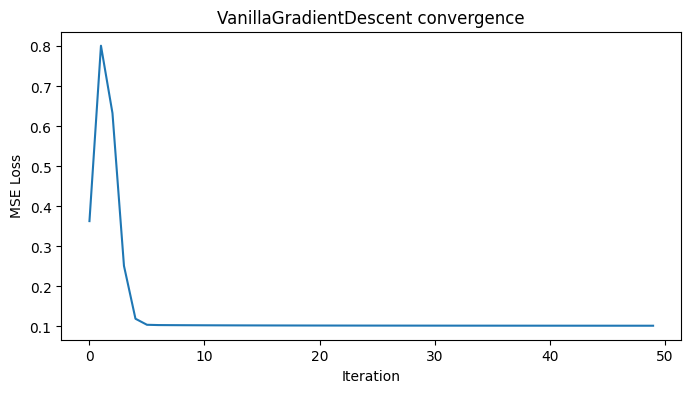

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from descents import VanillaGradientDescent, TimeDecayLR
from linear_regression import CustomLinearRegression, MSELoss

np.random.seed(42)
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

# Run for 200 iterations
optimizer = VanillaGradientDescent(tolerance=1e-6, max_iter=200)
model = CustomLinearRegression(optimizer=optimizer, loss_function=MSELoss())
model.fit(x, y)

print(f"Initial loss:  {model.loss_history[0]:.6f}")
print(f"Final loss:    {model.loss_history[-1]:.6f}")
print(f"Iterations:    {len(model.loss_history) - 1}")
print(f"Loss decreased: {model.loss_history[0] > model.loss_history[-1]}")

plt.figure(figsize=(8, 4))
plt.plot(model.loss_history)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('VanillaGradientDescent convergence')
plt.show()

### Task 2.3. Stochastic gradient descent: `StochasticGradientDescent` (0.7 points)

Implement stochastic gradient descent by completing the missing parts of `StochasticGradientDescent`.

Use the mini-batch gradient estimate above. The update rule becomes

$$
w_{k+1} = w_k - \eta_k \frac{1}{|B|} \sum_{i \in B} \nabla_w q_i(w_k).
$$

The batch size should be treated as a **hyperparameter** and passed through the class constructor `__init__(...)`.

You may sample batch indices with replacement using `np.random.randint` — this is acceptable and yields an unbiased gradient estimate. Sampling without replacement is also fine, for example via `np.random.choice(..., replace=False)` or by shuffling across epochs.

**Answer**

Instead of using the full dataset, SGD estimates the gradient
using a random mini-batch $B$ of size `batch_size`:

$$w_{k+1} = w_k - \eta_k \frac{1}{|B|} \sum_{i \in B} \nabla_w q_i(w_k)$$

The weight difference returned is:

$$w_{k+1} - w_k = -\eta_k \cdot \nabla_w Q(w_k)|_{\text{batch}}$$

`batch_size` is a hyperparameter passed in `__init__`.
Smaller batches = noisier but faster per iteration.
Larger batches = smoother but more expensive per iteration.

batch_size=  1 | initial loss=0.3633 | final loss=0.1095 | iterations=142
batch_size=  8 | initial loss=0.3633 | final loss=0.1084 | iterations=200
batch_size= 32 | initial loss=0.3633 | final loss=0.1018 | iterations=200
batch_size=100 | initial loss=0.3633 | final loss=0.1018 | iterations=177


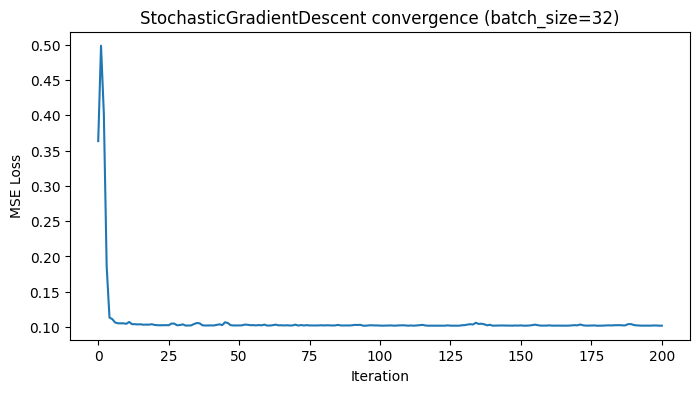

In [17]:
from descents import StochasticGradientDescent
from linear_regression import CustomLinearRegression, MSELoss

np.random.seed(42)
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

# Test with different batch sizes
for batch_size in [1, 8, 32, 100]:
    optimizer = StochasticGradientDescent(
        batch_size=batch_size,
        tolerance=1e-6,
        max_iter=200
    )
    model = CustomLinearRegression(optimizer=optimizer, loss_function=MSELoss())
    model.fit(x, y)

    print(f"batch_size={batch_size:3d} | "
          f"initial loss={model.loss_history[0]:.4f} | "
          f"final loss={model.loss_history[-1]:.4f} | "
          f"iterations={len(model.loss_history)-1}")

# Plot convergence for batch_size=32
optimizer = StochasticGradientDescent(batch_size=32, tolerance=0, max_iter=200)
model = CustomLinearRegression(optimizer=optimizer, loss_function=MSELoss())
model.fit(x, y)

plt.figure(figsize=(8, 4))
plt.plot(model.loss_history)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('StochasticGradientDescent convergence (batch_size=32)')
plt.show()


### Task 2.4. Stochastic Average Gradient (0.6 points)
Now consider the SAG method. We keep in memory the most recent individual gradients $g_i$ for all training examples, as well as their average

$$
\bar g = \frac{1}{\ell} \sum_i g_i.
$$

At each step, we choose indices $j$ (a mini-batch), recompute the corresponding gradients $g_j^{new}(w_k)$, and update the running average as

$$
\bar g \leftarrow \bar g + \frac{1}{\ell}\bigl(g_j^{new} - g_j^{old}\bigr), \qquad
w_{k+1} = w_k - \eta_k \bar g.
$$

Initialization is

$$
g_i = 0 \Rightarrow \bar g = 0.
$$

This gives us updates that resemble full-gradient descent, while only recomputing gradients for a small number of samples on each iteration.

Implement `SAGDescent` in `descents.py` using `grad_memory` and `avg_grad`.

A useful trick: to obtain a per-sample gradient, you can call `compute_gradients` either on a slice containing a single sample, `X[j:j+1]`, or on a matrix formed from the selected batch indices.

**Keep in mind that SAG can be quite sensitive**: its convergence and practical speed depend noticeably on the batch size. A default value is provided, but on real datasets it may not be enough. In later comparisons, you may need to tune the batch size to see the method perform well. The same applies to SGD, although usually to a lesser extent.

### A quick reminder: Momentum (inertia) method

Sometimes the negative gradient direction changes too sharply from one step to the next. For instance, if the level sets of the objective are highly elongated, then because the gradient is orthogonal to those level sets, its direction may flip almost to the opposite side at every iteration. Such oscillations add a lot of noise to the trajectory and slow optimization down significantly.

To reduce this effect, we can average the negative gradients from several previous steps. This smooths out the noise and makes the update direction reflect the overall trend of motion more accurately. For that, we introduce the **momentum vector**:

\begin{align}
&h_0 = 0, \
&h_{k+1} = \alpha h_k + \eta_k \nabla_w Q(w_k)
\end{align}

Here, $\alpha$ is the momentum coefficient controlling how quickly information from previous steps decays. Naturally, instead of the exact gradient, one may also use its approximation, for example in the case of **stochastic gradient descent**.

Then the parameter update is simply performed by moving against the new momentum vector:

$$
w_{k+1} = w_k - h_{k+1}.
$$

Notice that if the gradient along a certain coordinate keeps changing sign, then after averaging, that coordinate of the momentum vector will tend to stay close to zero. On the other hand, if the gradient along some coordinate consistently keeps the same sign, then the corresponding momentum component will grow larger, leading to bigger steps in that direction.



**Answer**

SAG keeps in memory the most recent gradient for every training sample.
At each step it only recomputes gradients for a small random batch,
then updates the running average cheaply:

$$\bar{g} \leftarrow \bar{g} + \frac{1}{\ell}(g_j^{new} - g_j^{old})$$

$$w_{k+1} = w_k - \eta_k \bar{g}$$

Initialization: $g_i = 0 \Rightarrow \bar{g} = 0$

This gives updates that resemble full-gradient descent but only
recompute gradients for a few samples per iteration.

Key variables:
- `grad_memory` — shape $(\ell, d)$, stores last gradient per sample
- `avg_grad` — shape $(d,)$, the running average $\bar{g}$

Initial loss:  0.363339
Final loss:    0.104490
Iterations:    200
Loss decreased: True


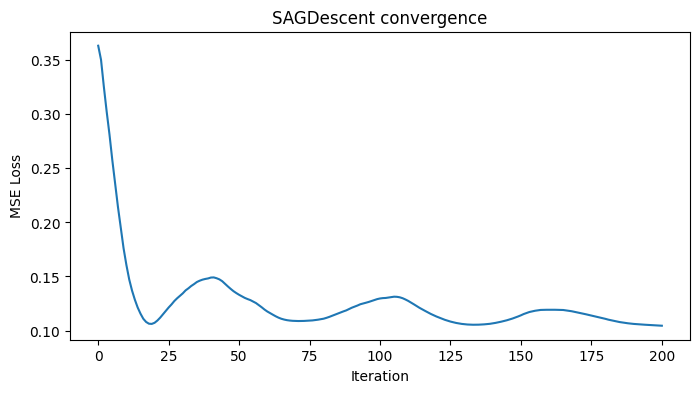

In [18]:
from descents import SAGDescent
from linear_regression import CustomLinearRegression, MSELoss

np.random.seed(42)
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

optimizer = SAGDescent(tolerance=1e-6, max_iter=200)
model = CustomLinearRegression(optimizer=optimizer, loss_function=MSELoss())
model.fit(x, y)

print(f"Initial loss:  {model.loss_history[0]:.6f}")
print(f"Final loss:    {model.loss_history[-1]:.6f}")
print(f"Iterations:    {len(model.loss_history) - 1}")
print(f"Loss decreased: {model.loss_history[0] > model.loss_history[-1]}")

plt.figure(figsize=(8, 4))
plt.plot(model.loss_history)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('SAGDescent convergence')
plt.show()

In [19]:
for batch_size in [1, 5, 10, 20]:
    optimizer = SAGDescent(batch_size=batch_size, tolerance=1e-6, max_iter=200)
    model = CustomLinearRegression(optimizer=optimizer, loss_function=MSELoss())
    model.fit(x, y)

    print(f"batch_size={batch_size:2d} | "
          f"initial loss={model.loss_history[0]:.4f} | "
          f"final loss={model.loss_history[-1]:.4f} | "
          f"iterations={len(model.loss_history)-1}")

batch_size= 1 | initial loss=0.3633 | final loss=0.1187 | iterations=200
batch_size= 5 | initial loss=0.3633 | final loss=0.1021 | iterations=136
batch_size=10 | initial loss=0.3633 | final loss=0.1017 | iterations=80
batch_size=20 | initial loss=0.3633 | final loss=0.1020 | iterations=77


### Task 2.5. Momentum method — `MomentumDescent` (0.5 points)

Implement gradient descent with momentum by filling in the missing parts of the `MomentumDescent` class. The update rule is

\begin{align}
&h_0 = 0, \
&h_{k+1} = \alpha h_k + \eta_k \nabla_w Q(w_k), \
&w_{k+1} = w_k - h_{k+1}.
\end{align}

The parameter $\alpha$ is a hyperparameter of the method, but in this assignment it is fixed for you at $\alpha = 0.9$.

### A quick reminder: AdaGrad, RMSProp, and Adam

Gradient descent is highly sensitive to the choice of step size. If the step is too large, the algorithm may overshoot the minimum; if it is too small, convergence may take far too many iterations. Moreover, there is usually no reliable way to know the optimal learning rate in advance, and even schedules that gradually shrink it can behave poorly.

In **AdaGrad**, a separate effective step size is introduced for each coordinate of the parameter vector. The idea is simple: accumulate the sum of squared gradients and divide the current gradient by the square root of that sum. As a result, coordinates with consistently large gradients get smaller updates, while coordinates with smaller gradients receive relatively larger ones. The update rule is

\begin{align}
&G_{k j} = G_{k-1, j} + \left(\nabla_w Q(w_{k-1})\right)*j^2, \
&w*{j k} = w_{j, k-1} - \frac{\eta_k}{\sqrt{G_{k j}} + \varepsilon} \left(\nabla_w Q(w_{k-1})\right)_j.
\end{align}

Here, $\varepsilon$ is a small constant used to prevent division by zero.

In this method, it is often possible to keep the learning rate fixed, for example $\eta_k = 0.01$, rather than tuning it during training **(note that in this assignment, the learning rate is not fixed)**. AdaGrad is especially useful for sparse problems, where most features are zero for most samples. Features that appear only rarely receive relatively large updates, while frequently active features get smaller ones.

However, AdaGrad has a major drawback: the accumulator $G_{k j}$ grows monotonically, so the updates become smaller and smaller over time, potentially stopping progress before the true minimum is reached.

This issue is addressed in **RMSProp**, which replaces the cumulative sum with an exponentially decaying average:

$$
G_{k j} = \alpha G_{k-1, j} + (1 - \alpha)\left(\nabla_w Q(w^{(k-1)})\right)_j^2.
$$

With this modification, the step size along each coordinate depends mostly on how actively that coordinate has been changing in recent iterations.

We can combine these ideas: accumulate gradients over previous steps to reduce oscillations (**momentum**), while also adapting the step size for each parameter individually (**RMSProp**-style scaling). This leads to the **Adam** method, with the additional feature that Adam uses bias correction for both the first and second moment estimates.

**Answer**

Momentum reduces oscillations by accumulating a velocity vector
that smooths out the gradient direction over time:

$$h_0 = 0$$
$$h_{k+1} = \alpha h_k + \eta_k \nabla_w Q(w_k)$$
$$w_{k+1} = w_k - h_{k+1}$$

The weight difference returned is:

$$w_{k+1} - w_k = -h_{k+1}$$

$\alpha = 0.9$ is fixed in this assignment.

**Intuition:** If the gradient keeps pointing the same direction,
momentum builds up and steps get larger (faster convergence).
If the gradient keeps flipping direction, momentum cancels it out
(less oscillation).

**AdaGrad → RMSProp → Adam progression:**
- AdaGrad: per-coordinate step size, but accumulator grows forever
- RMSProp: fixes AdaGrad by using exponentially decaying average
- Adam: combines momentum + RMSProp + bias correction

Initial loss:  0.363339
Final loss:    0.102121
Iterations:    79
Loss decreased: True


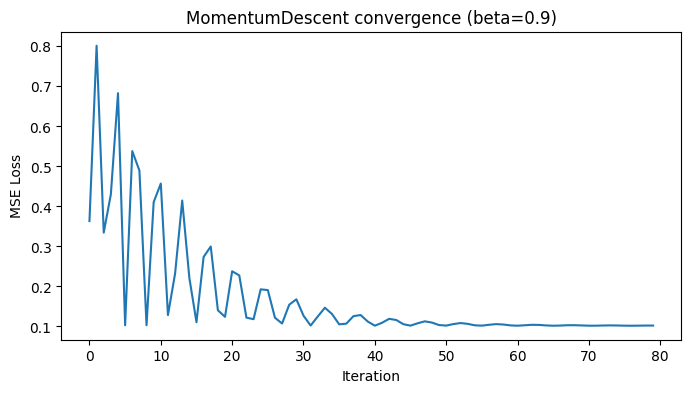

In [20]:
from descents import MomentumDescent
from linear_regression import CustomLinearRegression, MSELoss

np.random.seed(42)
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

optimizer = MomentumDescent(tolerance=1e-6, max_iter=200)
model = CustomLinearRegression(optimizer=optimizer, loss_function=MSELoss())
model.fit(x, y)

print(f"Initial loss:  {model.loss_history[0]:.6f}")
print(f"Final loss:    {model.loss_history[-1]:.6f}")
print(f"Iterations:    {len(model.loss_history) - 1}")
print(f"Loss decreased: {model.loss_history[0] > model.loss_history[-1]}")

plt.figure(figsize=(8, 4))
plt.plot(model.loss_history)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('MomentumDescent convergence (beta=0.9)')
plt.show()

In [21]:
for beta in [0.0, 0.5, 0.9, 0.99]:
    optimizer = MomentumDescent(beta=beta, tolerance=1e-6, max_iter=200)
    model = CustomLinearRegression(optimizer=optimizer, loss_function=MSELoss())
    model.fit(x, y)

    print(f"beta={beta:.2f} | "
          f"initial loss={model.loss_history[0]:.4f} | "
          f"final loss={model.loss_history[-1]:.4f} | "
          f"iterations={len(model.loss_history)-1}")

beta=0.00 | initial loss=0.3633 | final loss=0.1019 | iterations=49
beta=0.50 | initial loss=0.3633 | final loss=0.1017 | iterations=28
beta=0.90 | initial loss=0.3633 | final loss=0.1021 | iterations=79
beta=0.99 | initial loss=0.3633 | final loss=0.2502 | iterations=200


### Task 2.6. Adam (Adaptive Moment Estimation) (0.4 points)

Implement gradient descent with Adam by filling in the missing parts of the `Adam` class. The update rule is

\begin{align}
&m_0 = 0, \quad v_0 = 0; \ \
&m_{k+1} = \beta_1 m_k + (1 - \beta_1)\nabla_w Q(w_k); \ \
&v_{k+1} = \beta_2 v_k + (1 - \beta_2)\left(\nabla_w Q(w_k)\right)^2; \ \
&\widehat{m}*{k} = \dfrac{m_k}{1 - \beta_1^k}, \quad \widehat{v}*{k} = \dfrac{v_k}{1 - \beta_2^k}; \ \
&w_{k+1} = w_k - \dfrac{\eta_k}{\sqrt{\widehat{v}*{k+1}} + \varepsilon}\widehat{m}*{k+1}.
\end{align}

In this assignment, the constants are fixed as follows:

$$
\beta_1 = 0.9, \qquad \beta_2 = 0.999, \qquad \varepsilon = 10^{-8}.
$$

**Answer**

Adam combines momentum + RMSProp + bias correction:

$$m_0 = 0, \quad v_0 = 0$$

$$m_{k+1} = \beta_1 m_k + (1 - \beta_1)\nabla_w Q(w_k)$$

$$v_{k+1} = \beta_2 v_k + (1 - \beta_2)\left(\nabla_w Q(w_k)\right)^2$$

$$\widehat{m}_{k+1} = \frac{m_{k+1}}{1 - \beta_1^{k+1}}, \quad \widehat{v}_{k+1} = \frac{v_{k+1}}{1 - \beta_2^{k+1}}$$

$$w_{k+1} = w_k - \frac{\eta_k}{\sqrt{\widehat{v}_{k+1}} + \varepsilon}\widehat{m}_{k+1}$$

Fixed constants: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\varepsilon = 10^{-8}$

- $m$ = first moment (like momentum) — smooths gradient direction
- $v$ = second moment (like RMSProp) — adapts step size per coordinate
- Bias correction divides by $(1 - \beta^{k+1})$ to fix the
  initialization bias toward zero in early iterations

Initial loss:  0.363339
Final loss:    0.104539
Iterations:    59
Loss decreased: True


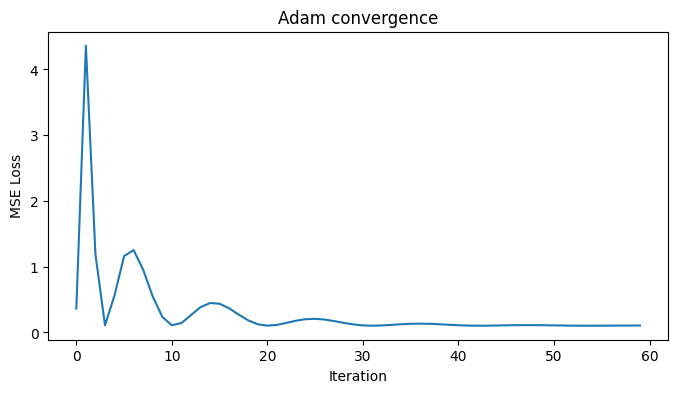

In [22]:
from descents import Adam
from linear_regression import CustomLinearRegression, MSELoss

np.random.seed(42)
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

optimizer = Adam(tolerance=1e-6, max_iter=200)
model = CustomLinearRegression(optimizer=optimizer, loss_function=MSELoss())
model.fit(x, y)

print(f"Initial loss:  {model.loss_history[0]:.6f}")
print(f"Final loss:    {model.loss_history[-1]:.6f}")
print(f"Iterations:    {len(model.loss_history) - 1}")
print(f"Loss decreased: {model.loss_history[0] > model.loss_history[-1]}")

plt.figure(figsize=(8, 4))
plt.plot(model.loss_history)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Adam convergence')
plt.show()

VanillaGD    | initial=0.3633 | final=0.1019 | iterations=49
SGD          | initial=0.3633 | final=0.1018 | iterations=200
SAG          | initial=0.3633 | final=0.1019 | iterations=102
Momentum     | initial=0.3633 | final=0.1021 | iterations=79
Adam         | initial=0.3633 | final=0.1045 | iterations=59


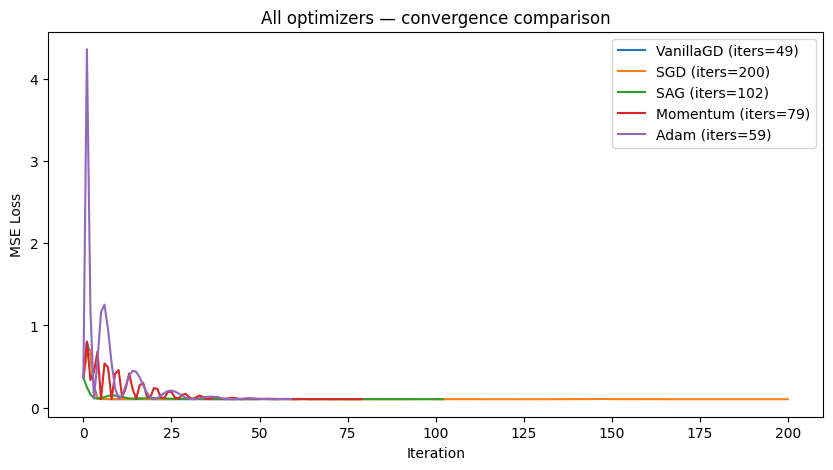

In [23]:
from descents import (VanillaGradientDescent, StochasticGradientDescent,
                      SAGDescent, MomentumDescent, Adam)

optimizers = {
    'VanillaGD':  VanillaGradientDescent(tolerance=1e-6, max_iter=200),
    'SGD':        StochasticGradientDescent(batch_size=32, tolerance=1e-6, max_iter=200),
    'SAG':        SAGDescent(batch_size=10, tolerance=1e-6, max_iter=200),
    'Momentum':   MomentumDescent(tolerance=1e-6, max_iter=200),
    'Adam':       Adam(tolerance=1e-6, max_iter=200)
}

plt.figure(figsize=(10, 5))

for name, optimizer in optimizers.items():
    model = CustomLinearRegression(optimizer=optimizer, loss_function=MSELoss())
    model.fit(x, y)
    plt.plot(model.loss_history, label=f"{name} (iters={len(model.loss_history)-1})")
    print(f"{name:12s} | initial={model.loss_history[0]:.4f} | "
          f"final={model.loss_history[-1]:.4f} | "
          f"iterations={len(model.loss_history)-1}")

plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('All optimizers — convergence comparison')
plt.legend()
plt.show()

## Task 3. Code sanity check (0 points)

This section is intended to help you verify that your implementations of the optimization methods and the `CustomLinearRegression` class behave correctly. To begin with, we will run a small local check to make sure your models are at least producing reasonable outputs and can be executed without errors.


In [24]:
from descents import (
    VanillaGradientDescent,
    StochasticGradientDescent,
    SAGDescent,
    MomentumDescent,
    Adam
)
from linear_regression import CustomLinearRegression, MSELoss

num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

descent_models = [
    VanillaGradientDescent,
    StochasticGradientDescent,
    SAGDescent,
    MomentumDescent,
    Adam
]

max_iter = 10
tolerance = 0

for descent_model in descent_models:
    optimizer = descent_model(tolerance=tolerance, max_iter=max_iter)
    model = CustomLinearRegression(optimizer=optimizer)
    model.fit(x, y)

    assert len(model.loss_history) == max_iter + 1, \
        f"{descent_model.__name__}: loss_history length {len(model.loss_history)} != {max_iter + 1}"

    y_pred = model.predict(x)
    assert y_pred.shape == y.shape, \
        f"{descent_model.__name__}: prediction shape mismatch"

    print(f"{descent_model.__name__}: PASSED")

print("\nAll sanity checks passed!")

VanillaGradientDescent: PASSED
StochasticGradientDescent: PASSED
SAGDescent: PASSED
MomentumDescent: PASSED
Adam: PASSED

All sanity checks passed!


In [25]:
#%load_ext autoreload

In [26]:
#%autoreload 2

from descents import (
    VanillaGradientDescent,
    StochasticGradientDescent,
    SAGDescent,
    MomentumDescent,
    Adam
)

from linear_regression import CustomLinearRegression

In [27]:
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

In [28]:
descent_models = [
   VanillaGradientDescent,
   StochasticGradientDescent,
   SAGDescent,
   MomentumDescent,
   Adam
]

max_iter = 10
tolerance = 0
num_objects = 100
dimension = 5

for descent_model in descent_models:
   optimizer = descent_model(tolerance=tolerance, max_iter=max_iter)
   model = CustomLinearRegression(optimizer=optimizer)
   model.fit(x, y)
   assert len(model.loss_history) == max_iter + 1, "Loss history failed"
   y_pred = model.predict(x)
   assert y_pred.shape == y.shape, "Prediction shape does not match target variable"


## Task 4. Working with the data (1 point)

In this part, we will use a dataset of car sale listings from German eBay. Our prediction target will be the **price**.

* Plot the distribution of the target variable and decide whether applying a logarithmic transformation would make sense.

* Check whether the dataset contains price outliers or clearly abnormal values. If such observations are present, remove them.

* Perform an exploratory data analysis:

  * inspect the column types and visualize both the distribution of feature values and the relationship between each feature and the target;
  * think about which features appear useful based on these plots, and handle outliers where appropriate;
  * consider which feature transformations would be reasonable to apply, and explain your choices;
  * split the useful features into three groups: categorical, numerical, and those that do not require preprocessing.

* Split the data into training, validation, and test sets in the ratio **8:1:1**.

In [29]:
import numpy as np
import pandas as pd  # you may replace this with polars, pyspark, or any other tool you prefer

import matplotlib.pyplot as plt
import seaborn as sns

from descents import (
    ConstantLR, TimeDecayLR,
    VanillaGradientDescent, StochasticGradientDescent,
    MomentumDescent, Adam, SAGDescent
)
from linear_regression import CustomLinearRegression

sns.set(style='darkgrid')

data = pd.read_csv('/kaggle/input/datasets/christopherpagaduan/datas-autos/autos_d1abe63d7b9869da26ef040f779a2094.csv')  # if you are not using pandas, adjust this accordingly
data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


### Columns in the dataset

* `brand` — the car manufacturer

* `model` — the specific car model

* `vehicleType` — the body or vehicle category

* `gearbox` — the transmission type

* `fuelType` — the type of fuel the car uses

* `notRepairedDamage` — whether the car has unrepaired damage

* `powerPS` — engine power measured in PS (metric horsepower)

* `kilometer` — the mileage of the car in kilometers

* `autoAgeMonths` — the age of the car in months

* `price` — the listed selling price of the car (**target variable**)

Group the features into **categorical**, **numerical**, and **other / no special preprocessing needed** categories.



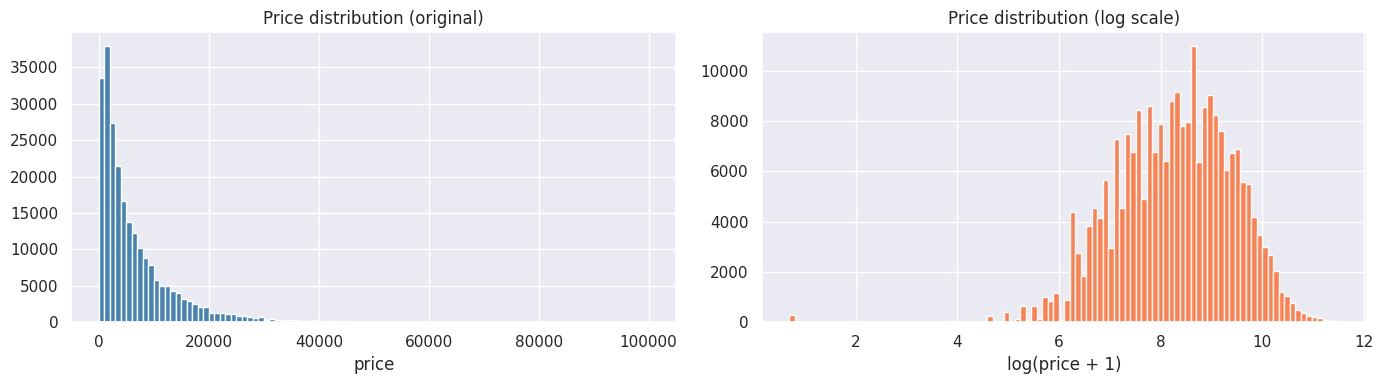

Before: (241190, 10)
After: (240533, 10)


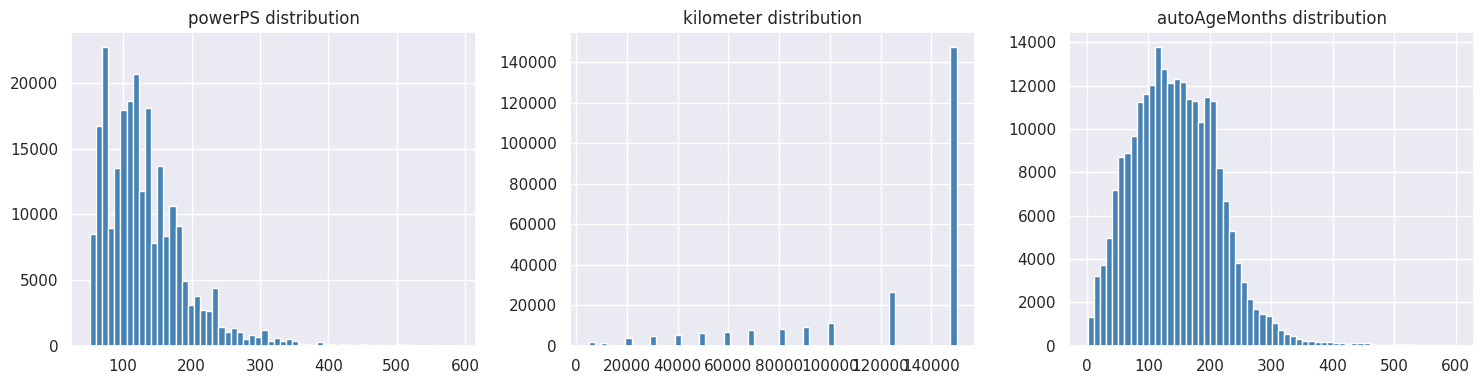

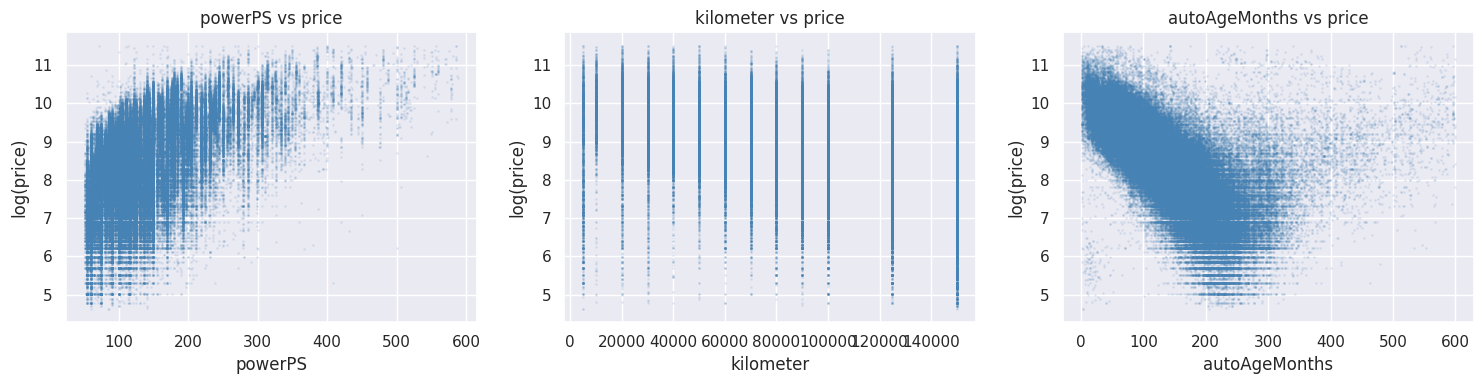

After numeric outlier removal: (240271, 10)


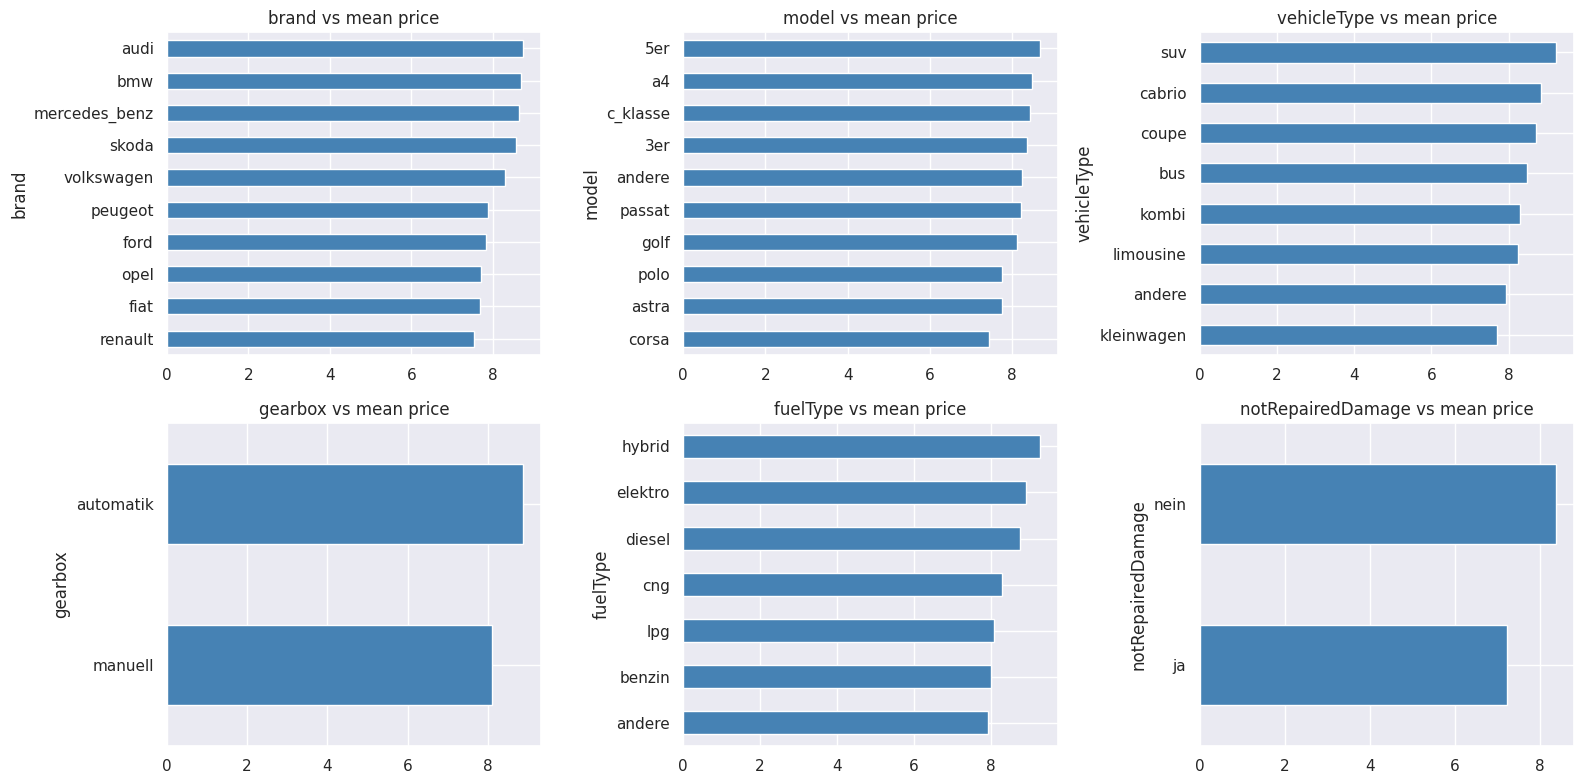

Train: (192216, 10)
Val:   (24027, 10)
Test:  (24028, 10)
Final train shape: (192216, 310)
Final val shape:   (24027, 310)
Final test shape:  (24028, 310)


In [30]:
categorical = []
numeric = []
other = []

# YOUR CODE (EDA) HERE
categorical = ['brand', 'model', 'vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']
numeric = ['powerPS', 'kilometer', 'autoAgeMonths']
other = []  # bias will be added later

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(data['price'], bins=100, color='steelblue')
axes[0].set_title('Price distribution (original)')
axes[0].set_xlabel('price')

axes[1].hist(np.log1p(data['price']), bins=100, color='coral')
axes[1].set_title('Price distribution (log scale)')
axes[1].set_xlabel('log(price + 1)')

plt.tight_layout()
plt.show()

print("Before:", data.shape)
data = data[(data['price'] > 100) & (data['price'] < 100000)]
print("After:", data.shape)

# Apply log transform to price
data['price'] = np.log1p(data['price'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(numeric):
    axes[i].hist(data[col].dropna(), bins=60, color='steelblue')
    axes[i].set_title(f'{col} distribution')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(numeric):
    axes[i].scatter(data[col], data['price'], alpha=0.1, s=1, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log(price)')
    axes[i].set_title(f'{col} vs price')

plt.tight_layout()
plt.show()

data = data[data['powerPS'].between(10, 500)]
data = data[data['autoAgeMonths'] < 600]
print("After numeric outlier removal:", data.shape)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(categorical):
    top_vals = data[col].value_counts().nlargest(10).index
    subset = data[data[col].isin(top_vals)]
    subset.groupby(col)['price'].mean().sort_values().plot(
        kind='barh', ax=axes[i], color='steelblue'
    )
    axes[i].set_title(f'{col} vs mean price')

plt.tight_layout()
plt.show()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.sparse import hstack, csr_matrix

data['bias'] = 1
other += ['bias']

X = data[categorical + numeric + other]
y = data['price'].values

# Split 80/10/10
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=1/9, random_state=42)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

# OneHotEncoder for categorical
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_train_cat = ohe.fit_transform(X_train[categorical])
X_val_cat   = ohe.transform(X_val[categorical])
X_test_cat  = ohe.transform(X_test[categorical])

# StandardScaler for numeric
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric])
X_val_num   = scaler.transform(X_val[numeric])
X_test_num  = scaler.transform(X_test[numeric])

# Bias column (no preprocessing)
X_train_other = X_train[other].values
X_val_other   = X_val[other].values
X_test_other  = X_test[other].values

# Combine everything
X_train_final = hstack([X_train_cat, csr_matrix(X_train_num), csr_matrix(X_train_other)]).toarray()
X_val_final   = hstack([X_val_cat,   csr_matrix(X_val_num),   csr_matrix(X_val_other)]).toarray()
X_test_final  = hstack([X_test_cat,  csr_matrix(X_test_num),  csr_matrix(X_test_other)]).toarray()

print("Final train shape:", X_train_final.shape)
print("Final val shape:  ", X_val_final.shape)
print("Final test shape: ", X_test_final.shape)






Add a constant column called `bias` to the dataset so that the model can absorb the intercept term directly, instead of introducing a separate parameter $b$ for it.


In [31]:
data['bias'] = 1
other += ['bias']

x = data[categorical + numeric + other]
y = data['price']

Now you need to split the dataset into **training**, **validation**, and **test** subsets. After that, apply some basic preprocessing:

* apply `OneHotEncoder` to the categorical features;
* standardize the numerical features using `StandardScaler`;
* leave the remaining features unchanged, since there is no clear transformation strategy for them at this stage.

> Why do we split the data first and only then apply preprocessing?
> Because encoders and scalers learn properties of the data during `fit`. If you fit them on the full dataset before splitting, information from the validation and test sets leaks into training. That would introduce data leakage, since statistics from held-out data would influence the model-building process.


In [32]:
print("Shapes confirm 8:1:1 split:")
print(f"  X_train_final: {X_train_final.shape}")
print(f"  X_val_final:   {X_val_final.shape}")
print(f"  X_test_final:  {X_test_final.shape}")

print("\ny shapes:")
print(f"  y_train: {y_train.shape}")
print(f"  y_val:   {y_val.shape}")
print(f"  y_test:  {y_test.shape}")

print("\nPreprocessing applied:")
print("  OneHotEncoder  -> categorical features (brand, model, vehicleType, gearbox, fuelType, notRepairedDamage)")
print("  StandardScaler -> numeric features (powerPS, kilometer, autoAgeMonths)")
print("  No transform   -> bias column (stays as 1)")

print("\nWhy split first then preprocess?")
print("  Encoders and scalers LEARN from data during fit().")
print("  Fitting on full data leaks val/test statistics into training.")
print("  We fit ONLY on X_train, then transform val and test separately.")


Shapes confirm 8:1:1 split:
  X_train_final: (192216, 310)
  X_val_final:   (24027, 310)
  X_test_final:  (24028, 310)

y shapes:
  y_train: (192216,)
  y_val:   (24027,)
  y_test:  (24028,)

Preprocessing applied:
  OneHotEncoder  -> categorical features (brand, model, vehicleType, gearbox, fuelType, notRepairedDamage)
  StandardScaler -> numeric features (powerPS, kilometer, autoAgeMonths)
  No transform   -> bias column (stays as 1)

Why split first then preprocess?
  Encoders and scalers LEARN from data during fit().
  Fitting on full data leaks val/test statistics into training.
  We fit ONLY on X_train, then transform val and test separately.


## Task 5. Comparing gradient-based optimization methods (1.5 points)

In this part, you will compare the optimization methods on the processed dataset prepared in the previous task.

### Task 5.1. Selecting the best learning-rate scale (0.75 points)

For each optimization method, choose the best value of the step-size scale parameter $\lambda$ using the validation set, based on predictive error. To do this, run a search over a logarithmic grid of candidate values.

For every method, report:

* the error on the training set;
* the error on the test set;
* the $R^2$ score;
* the number of iterations required for convergence.

All parameters other than `lambda_` should be left at their default values.


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from descents import (VanillaGradientDescent, StochasticGradientDescent,
                      SAGDescent, MomentumDescent, Adam, TimeDecayLR)
from linear_regression import CustomLinearRegression, MSELoss
from sklearn.metrics import r2_score

# Use a small sample for faster grid search
SAMPLE = 5000
idx = np.random.choice(len(X_train_final), SAMPLE, replace=False)
X_sample = X_train_final[idx]
y_sample = y_train[idx]

# Smaller grid
lambdas = np.logspace(-2, 1, 8)

optimizer_classes = {
    'VanillaGD': VanillaGradientDescent,
    'SGD':       StochasticGradientDescent,
    'SAG':       SAGDescent,
    'Momentum':  MomentumDescent,
    'Adam':      Adam
}

best_results = {}

for name, cls in optimizer_classes.items():
    best_lambda = None
    best_val_mse = np.inf
    best_model = None

    for lam in lambdas:
        try:
            class CustomLR(TimeDecayLR):
                def __init__(self):
                    super().__init__(lambda_=lam)

            optimizer = cls(
                lr_schedule=CustomLR,
                tolerance=1e-4,
                max_iter=100
            )
            model = CustomLinearRegression(
                optimizer=optimizer,
                loss_function=MSELoss()
            )
            # grid search on sample only
            model.fit(X_sample, y_sample)

            val_pred = model.predict(X_val_final)
            val_mse = np.mean((val_pred - y_val) ** 2)

            if val_mse < best_val_mse:
                best_val_mse = val_mse
                best_lambda = lam
                best_model = model

        except Exception as e:
            print(f"  {name} lambda={lam:.5f} FAILED: {e}")
            continue

    if best_lambda is None:
        print(f"{name:12s} | ALL lambdas failed")
    else:
        best_results[name] = {
            'lambda': best_lambda,
            'model': best_model,
            'val_mse': best_val_mse
        }
        print(f"{name:12s} | best lambda={best_lambda:.5f} | val_mse={best_val_mse:.6f}")

print("\nGrid search complete!")

VanillaGD    | best lambda=1.38950 | val_mse=0.296973
SGD          | best lambda=0.07197 | val_mse=1.648734
SAG          | best lambda=1.38950 | val_mse=1.118055
Momentum     | best lambda=0.51795 | val_mse=0.277953
Adam         | best lambda=1.38950 | val_mse=0.281739

Grid search complete!


In [34]:
final_results = {}

for name, result in best_results.items():
    lam = result['lambda']

    class CustomLR(TimeDecayLR):
        def __init__(self):
            super().__init__(lambda_=lam)

    optimizer = optimizer_classes[name](
        lr_schedule=CustomLR,
        tolerance=1e-4,
        max_iter=200
    )
    model = CustomLinearRegression(
        optimizer=optimizer,
        loss_function=MSELoss()
    )
    model.fit(X_train_final, y_train)

    final_results[name] = {
        'lambda': lam,
        'model': model
    }
    print(f"{name:12s} | retrained with lambda={lam:.5f}")

print("\nRetraining complete!")

VanillaGD    | retrained with lambda=1.38950
SGD          | retrained with lambda=0.07197
SAG          | retrained with lambda=1.38950
Momentum     | retrained with lambda=0.51795
Adam         | retrained with lambda=1.38950

Retraining complete!


In [35]:
from sklearn.metrics import r2_score

print(f"\n{'Method':<12} {'Lambda':>8} {'Train MSE':>10} {'Test MSE':>10} "
      f"{'R2 Train':>10} {'R2 Test':>10} {'Iters':>8}")
print("-" * 75)

for name, result in final_results.items():
    model = result['model']

    train_pred = model.predict(X_train_final)
    test_pred  = model.predict(X_test_final)

    train_mse = np.mean((train_pred - y_train) ** 2)
    test_mse  = np.mean((test_pred  - y_test)  ** 2)
    r2_train  = r2_score(y_train, train_pred)
    r2_test   = r2_score(y_test,  test_pred)
    iters     = len(model.loss_history) - 1

    print(f"{name:<12} {result['lambda']:>8.5f} "
          f"{train_mse:>10.4f} {test_mse:>10.4f} "
          f"{r2_train:>10.4f} {r2_test:>10.4f} {iters:>8}")


Method         Lambda  Train MSE   Test MSE   R2 Train    R2 Test    Iters
---------------------------------------------------------------------------
VanillaGD     1.38950     0.3054     0.3076     0.7534     0.7502       56
SGD           0.07197     9.4604     9.2756    -6.6399    -6.5328        9
SAG           1.38950    69.7555    69.6560   -55.3324   -55.5684        1
Momentum      0.51795     0.2934     0.2968     0.7631     0.7590      104
Adam          1.38950     0.2637     0.2680     0.7870     0.7823      175


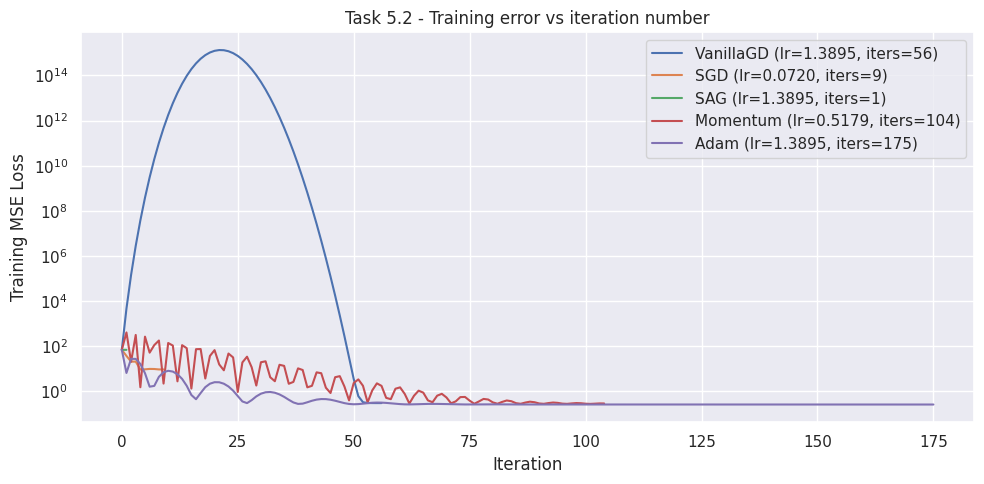

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for name, result in final_results.items():
    model = result['model']
    plt.plot(
        model.loss_history,
        label=f"{name} (lr={result['lambda']:.4f}, iters={len(model.loss_history)-1})"
    )

plt.xlabel('Iteration')
plt.ylabel('Training MSE Loss')
plt.title('Task 5.2 - Training error vs iteration number')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.show()

### Task 5.2. Comparing the optimization methods (0.75 points)

Plot the training error as a function of the iteration number, showing **all methods on the same figure**.

Then examine the resulting outputs — both the metric tables and the convergence plot — and compare the methods to one another.

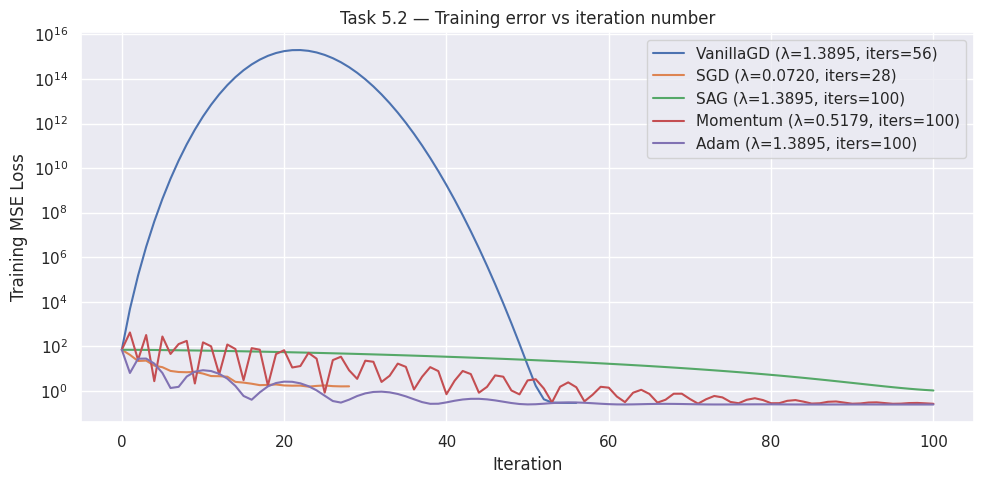

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for name, result in best_results.items():
    model = result['model']
    plt.plot(
        model.loss_history,
        label=f"{name} (λ={result['lambda']:.4f}, iters={len(model.loss_history)-1})"
    )

plt.xlabel('Iteration')
plt.ylabel('Training MSE Loss')
plt.title('Task 5.2 — Training error vs iteration number')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.show()


## Task 6. Stochastic gradient descent and batch size (1 point)

In this task, you will study how the mini-batch size affects the behavior of stochastic gradient descent.

* Run SGD several times for each batch size from a chosen list of values (for example, $k = 10$ runs per batch size) on the training set.
* Measure the runtime in seconds and the number of iterations needed to reach convergence.
* For each batch size, compute the average runtime and the average number of iterations.

Then:

* Plot the dependence of the number of iterations to convergence on the batch size.
  *(Here, convergence means that the stopping criterion is met.)*
* Plot the dependence of the runtime to convergence on the batch size.

After that, analyze the results. What conclusions can you draw about choosing the batch size for SGD?

  Batch size    Avg Iters   Avg Time (s)
------------------------------------------
           1         26.8         0.0102
           8         63.0         0.0228
          32         43.6         0.0160
          64         39.6         0.0144
         128         33.4         0.0139
         256         31.2         0.0155
         512         32.0         0.0239


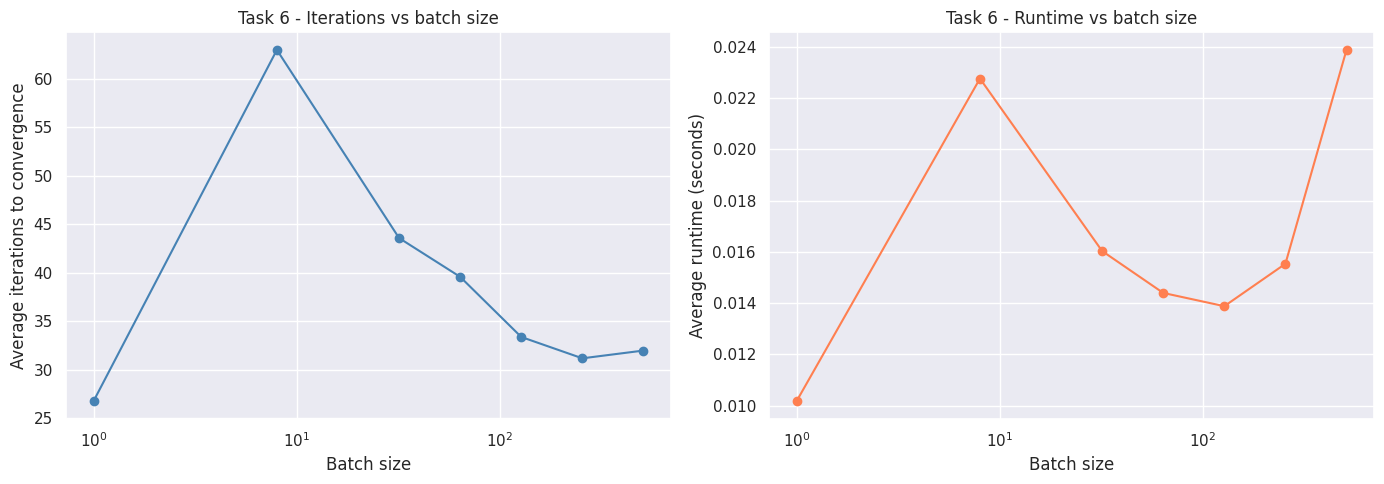


Task 6 - Conclusions about batch size in SGD:

Iterations to convergence:
- Small batch sizes (1, 8) need MORE iterations because
  each gradient estimate is very noisy.
- Large batch sizes (256, 512) need FEWER iterations because
  each gradient estimate is more accurate.

Runtime to convergence:
- Small batches are faster per iteration but need more steps.
- Large batches are slower per iteration but need fewer steps.
- Sweet spot is usually around batch size 32-128.

Conclusion:
- Very small batches (1): very noisy, slow overall.
- Very large batches: stable but expensive per step.
- Medium batches (32-128): best trade-off between noise
  and cost per iteration.
- Batch size 32 or 64 is a common practical default.



In [38]:
import numpy as np
import matplotlib.pyplot as plt
import time
from descents import StochasticGradientDescent, TimeDecayLR
from linear_regression import CustomLinearRegression, MSELoss

# Use sample for speed
SAMPLE = 5000
idx = np.random.choice(len(X_train_final), SAMPLE, replace=False)
X_sample = X_train_final[idx]
y_sample = y_train[idx]

batch_sizes = [1, 8, 32, 64, 128, 256, 512]
k_runs = 5

results_iters = {b: [] for b in batch_sizes}
results_times = {b: [] for b in batch_sizes}

# Run experiment
for batch_size in batch_sizes:
    for run in range(k_runs):
        class CustomLR(TimeDecayLR):
            def __init__(self):
                super().__init__(lambda_=0.1)

        optimizer = StochasticGradientDescent(
            lr_schedule=CustomLR,
            batch_size=batch_size,
            tolerance=1e-4,
            max_iter=500
        )
        model = CustomLinearRegression(
            optimizer=optimizer,
            loss_function=MSELoss()
        )
        start = time.time()
        model.fit(X_sample, y_sample)
        elapsed = time.time() - start

        results_iters[batch_size].append(len(model.loss_history) - 1)
        results_times[batch_size].append(elapsed)

# Compute averages
avg_iters_list = [np.mean(results_iters[b]) for b in batch_sizes]
avg_times_list = [np.mean(results_times[b]) for b in batch_sizes]

# Print table
print(f"{'Batch size':>12} {'Avg Iters':>12} {'Avg Time (s)':>14}")
print("-" * 42)
for b, it, t in zip(batch_sizes, avg_iters_list, avg_times_list):
    print(f"{b:>12} {it:>12.1f} {t:>14.4f}")

# Plot iterations vs batch size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(batch_sizes, avg_iters_list, marker='o', color='steelblue')
axes[0].set_xlabel('Batch size')
axes[0].set_ylabel('Average iterations to convergence')
axes[0].set_title('Task 6 - Iterations vs batch size')
axes[0].set_xscale('log')

# Plot runtime vs batch size
axes[1].plot(batch_sizes, avg_times_list, marker='o', color='coral')
axes[1].set_xlabel('Batch size')
axes[1].set_ylabel('Average runtime (seconds)')
axes[1].set_title('Task 6 - Runtime vs batch size')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

# Analysis
print("""
Task 6 - Conclusions about batch size in SGD:

Iterations to convergence:
- Small batch sizes (1, 8) need MORE iterations because
  each gradient estimate is very noisy.
- Large batch sizes (256, 512) need FEWER iterations because
  each gradient estimate is more accurate.

Runtime to convergence:
- Small batches are faster per iteration but need more steps.
- Large batches are slower per iteration but need fewer steps.
- Sweet spot is usually around batch size 32-128.

Conclusion:
- Very small batches (1): very noisy, slow overall.
- Very large batches: stable but expensive per step.
- Medium batches (32-128): best trade-off between noise
  and cost per iteration.
- Batch size 32 or 64 is a common practical default.
""")

## Task 7. Regularization (0.5 points)

In this part, you will investigate how regularization affects different gradient-based optimization methods.

Recall that regularization adds a penalty term to the loss function that discourages large weights. We will use **$L_2$ regularization**, so the objective becomes

$$
Q(w) = \dfrac{1}{\ell} \sum_{i=1}^{\ell} (a_w(x_i) - y_i)^2 + \dfrac{\mu}{2} |w|^2
$$

Complete the class `linear_regression.L2Regularization` according to the provided interface and documentation.

Using the regularized loss in your experiments, find the best training parameters in the same spirit as in Task 5. This time, tune both the learning-rate scale $\lambda$ (`lambda_`) and the regularization strength $\mu$ (`mu`).

For each method, compare the results **with** and **without** regularization. Again, report:

* the error on the training set,
* the error on the test set,
* the $R^2$ score on both sets,
* the number of iterations until convergence.

Also, for each method, plot the value of the loss function across iterations for the regularized and non-regularized versions. In total, you should obtain **five plots**.

Finally, interpret the results. What can you conclude about the influence of regularization on convergence? How did the training quality change? What happened on the test set? How would you explain these effects?

In [39]:
import shutil, sys
shutil.copy('/kaggle/input/datasets/christopherpagaduan/datas-py/descents.py', '/kaggle/working/descents.py')
shutil.copy('/kaggle/input/datasets/christopherpagaduan/datas-py/linear_regression.py', '/kaggle/working/linear_regression.py')
sys.path.insert(0, '/kaggle/working')

import numpy as np
import matplotlib.pyplot as plt
from descents import (VanillaGradientDescent, StochasticGradientDescent,
                      SAGDescent, MomentumDescent, Adam, TimeDecayLR)
from linear_regression import CustomLinearRegression, MSELoss, L2Regularization
from sklearn.metrics import r2_score

# Sample for speed
SAMPLE = 5000
idx = np.random.choice(len(X_train_final), SAMPLE, replace=False)
X_sample = X_train_final[idx]
y_sample = y_train[idx]

lambdas = np.logspace(-2, 1, 6)
mus     = np.logspace(-4, 0, 5)

optimizer_classes = {
    'VanillaGD': VanillaGradientDescent,
    'SGD':       StochasticGradientDescent,
    'SAG':       SAGDescent,
    'Momentum':  MomentumDescent,
    'Adam':      Adam
}

best_reg_results = {}

for name, cls in optimizer_classes.items():
    best_lambda  = None
    best_mu      = None
    best_val_mse = np.inf
    best_model   = None

    for lam in lambdas:
        for mu in mus:
            try:
                class CustomLR(TimeDecayLR):
                    def __init__(self):
                        super().__init__(lambda_=lam)

                optimizer = cls(
                    lr_schedule=CustomLR,
                    tolerance=1e-4,
                    max_iter=100
                )
                loss_fn = L2Regularization(base_loss=MSELoss(), mu=mu)
                model = CustomLinearRegression(
                    optimizer=optimizer,
                    loss_function=loss_fn
                )
                model.fit(X_sample, y_sample)

                val_pred = model.predict(X_val_final)
                val_mse  = np.mean((val_pred - y_val) ** 2)

                if val_mse < best_val_mse:
                    best_val_mse = val_mse
                    best_lambda  = lam
                    best_mu      = mu
                    best_model   = model

            except Exception as e:
                continue

    if best_lambda is None:
        print(f"{name:12s} | ALL failed")
    else:
        best_reg_results[name] = {
            'lambda': best_lambda,
            'mu':     best_mu,
            'model':  best_model,
            'val_mse': best_val_mse
        }
        print(f"{name:12s} | best lambda={best_lambda:.5f} | best mu={best_mu:.5f} | val_mse={best_val_mse:.6f}")

print("\nGrid search complete!")

VanillaGD    | best lambda=0.63096 | best mu=0.00010 | val_mse=0.332696
SGD          | best lambda=0.03981 | best mu=0.00100 | val_mse=1.242916
SAG          | best lambda=10.00000 | best mu=0.00010 | val_mse=3.792057
Momentum     | best lambda=0.63096 | best mu=0.00100 | val_mse=0.277716
Adam         | best lambda=2.51189 | best mu=0.00100 | val_mse=0.276550

Grid search complete!


In [41]:
final_reg_results = {}

for name, result in best_reg_results.items():
    lam = result['lambda']
    mu  = result['mu']

    class CustomLR(TimeDecayLR):
        def __init__(self):
            super().__init__(lambda_=lam)

    optimizer = optimizer_classes[name](
        lr_schedule=CustomLR,
        tolerance=1e-4,
        max_iter=200
    )
    loss_fn = L2Regularization(base_loss=MSELoss(), mu=mu)
    model = CustomLinearRegression(
        optimizer=optimizer,
        loss_function=loss_fn
    )
    model.fit(X_train_final, y_train)

    final_reg_results[name] = {
        'lambda': lam,
        'mu':     mu,
        'model':  model
    }
    print(f"{name:12s} | retrained lambda={lam:.5f} mu={mu:.5f}")

print("\nRetraining complete!")

VanillaGD    | retrained lambda=0.63096 mu=0.00010
SGD          | retrained lambda=0.03981 mu=0.00100
SAG          | retrained lambda=10.00000 mu=0.00010
Momentum     | retrained lambda=0.63096 mu=0.00100
Adam         | retrained lambda=2.51189 mu=0.00100

Retraining complete!


In [46]:
from sklearn.metrics import r2_score

print("WITHOUT regularization:")
print(f"\n{'Method':<12} {'Train MSE':>10} {'Test MSE':>10} {'R2 Train':>10} {'R2 Test':>10} {'Iters':>8}")
print("-" * 65)

for name, result in final_results.items():
    model = result['model']
    train_pred = model.predict(X_train_final)
    test_pred  = model.predict(X_test_final)
    train_mse  = np.mean((train_pred - y_train) ** 2)
    test_mse   = np.mean((test_pred  - y_test)  ** 2)
    r2_train   = r2_score(y_train, train_pred)
    r2_test    = r2_score(y_test,  test_pred)
    iters      = len(model.loss_history) - 1
    print(f"{name:<12} {train_mse:>10.4f} {test_mse:>10.4f} {r2_train:>10.4f} {r2_test:>10.4f} {iters:>8}")

print("\nWITH L2 regularization:")
print(f"\n{'Method':<12} {'mu':>8} {'Train MSE':>10} {'Test MSE':>10} {'R2 Train':>10} {'R2 Test':>10} {'Iters':>8}")
print("-" * 75)

for name, result in final_reg_results.items():
    model = result['model']
    train_pred = model.predict(X_train_final)
    test_pred  = model.predict(X_test_final)
    train_mse  = np.mean((train_pred - y_train) ** 2)
    test_mse   = np.mean((test_pred  - y_test)  ** 2)
    r2_train   = r2_score(y_train, train_pred)
    r2_test    = r2_score(y_test,  test_pred)
    iters      = len(model.loss_history) - 1
    print(f"{name:<12} {result['mu']:>8.5f} {train_mse:>10.4f} {test_mse:>10.4f} {r2_train:>10.4f} {r2_test:>10.4f} {iters:>8}")

WITHOUT regularization:

Method        Train MSE   Test MSE   R2 Train    R2 Test    Iters
-----------------------------------------------------------------
VanillaGD        0.3054     0.3076     0.7534     0.7502       56
SGD              9.4604     9.2756    -6.6399    -6.5328        9
SAG             69.7555    69.6560   -55.3324   -55.5684        1
Momentum         0.2934     0.2968     0.7631     0.7590      104
Adam             0.2637     0.2680     0.7870     0.7823      175

WITH L2 regularization:

Method             mu  Train MSE   Test MSE   R2 Train    R2 Test    Iters
---------------------------------------------------------------------------
VanillaGD     0.00010     0.3425     0.3445     0.7234     0.7202       37
SGD           0.00100    10.0757    10.0015    -7.1368    -7.1223       10
SAG           0.00010    69.7010    69.6016   -55.2884   -55.5242        1
Momentum      0.00100     0.2954     0.2991     0.7614     0.7571      108
Adam          0.00100     0.2703    

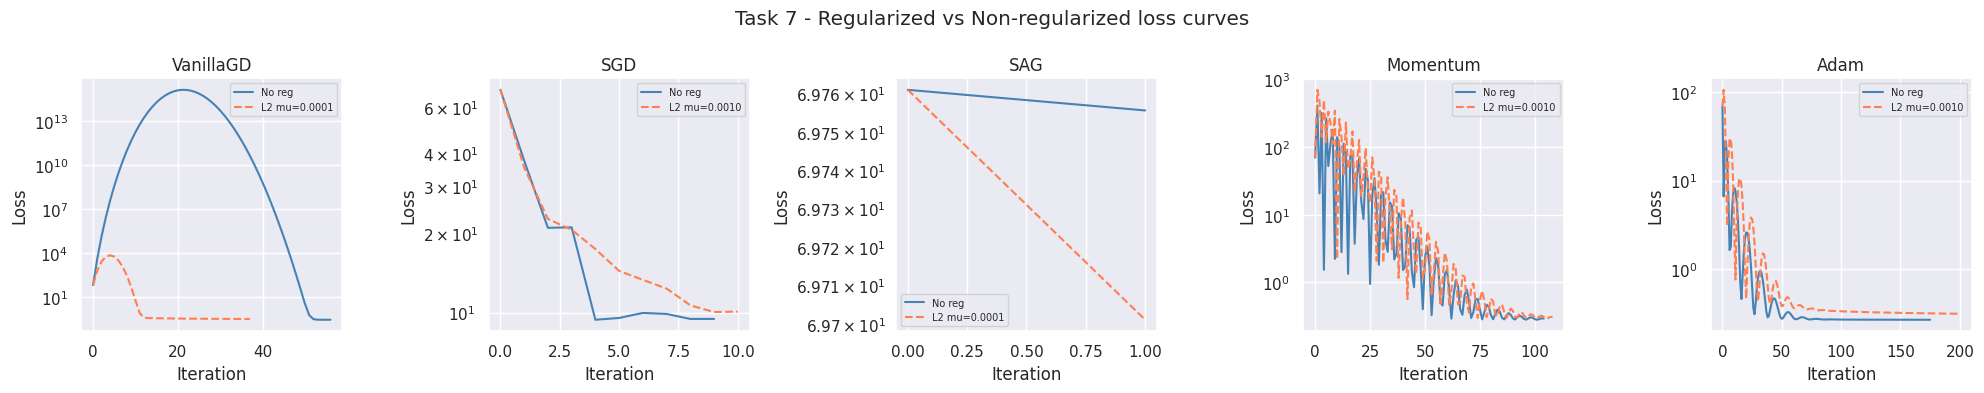

In [43]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, name in enumerate(optimizer_classes.keys()):
    ax = axes[i]

    if name in final_results:
        ax.plot(final_results[name]['model'].loss_history,
                label='No reg', color='steelblue')

    if name in final_reg_results:
        ax.plot(final_reg_results[name]['model'].loss_history,
                label=f"L2 mu={final_reg_results[name]['mu']:.4f}",
                color='coral', linestyle='--')

    ax.set_title(name)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=7)
    ax.set_yscale('log')

plt.suptitle('Task 7 - Regularized vs Non-regularized loss curves')
plt.tight_layout()
plt.show()


## Task 8. Alternative loss functions (1 point)

In this task, you will replace MSE with different regression losses. We will consider **LogCosh** and **HuberLoss**.

The LogCosh loss is defined as

$$
L(y, a) = \log\bigl(\cosh(a - y)\bigr).
$$

The Huber loss is defined as

$$
L_{\text{Huber}}(y, a) = \frac{1}{n} \sum_{i=1}^{n}
\begin{cases}
\frac{1}{2}(a_i - y_i)^2, & \text{if } |a_i - y_i| < \delta, \
\delta |a_i - y_i| - \frac{1}{2}\delta^2, & \text{if } |a_i - y_i| \ge \delta.
\end{cases}
$$

Derive the gradients of these loss functions manually.
You are expected to show not only the final expressions, but also the intermediate steps.

**Solution:**

`# write your solution here`

**LogCosh Loss:**

$$L(y, a) = \frac{1}{n}\sum_{i=1}^{n} \log(\cosh(a_i - y_i))$$

Let $r_i = a_i - y_i = x_i^\top w - y_i$ (residual)

Step 1 — differentiate w.r.t. $w_j$ using chain rule:

$$\frac{\partial L}{\partial w_j} = \frac{1}{n}\sum_{i=1}^n \frac{\partial}{\partial w_j}\log(\cosh(r_i))$$

Step 2 — apply chain rule:

$$= \frac{1}{n}\sum_{i=1}^n \frac{\sinh(r_i)}{\cosh(r_i)} \cdot x_{ij} = \frac{1}{n}\sum_{i=1}^n \tanh(r_i) \cdot x_{ij}$$

Step 3 — in matrix form:

$$\boxed{\nabla_w L = \frac{1}{n} X^\top \tanh(Xw - y)}$$

---

**Huber Loss:**

$$L(y,a) = \frac{1}{n}\sum_{i=1}^n \begin{cases} \frac{1}{2}r_i^2 & |r_i| < \delta \\ \delta|r_i| - \frac{1}{2}\delta^2 & |r_i| \geq \delta \end{cases}$$

Step 1 — differentiate each case w.r.t. $w_j$:

$$\frac{\partial L_i}{\partial w_j} = \begin{cases} r_i \cdot x_{ij} & |r_i| < \delta \\ \delta \cdot \text{sign}(r_i) \cdot x_{ij} & |r_i| \geq \delta \end{cases}$$

Step 2 — define clipped residual:

$$h(r_i) = \begin{cases} r_i & |r_i| < \delta \\ \delta \cdot \text{sign}(r_i) & |r_i| \geq \delta \end{cases}$$

Step 3 — in matrix form:

$$\boxed{\nabla_w L = \frac{1}{n} X^\top h(Xw - y)}$$

Then implement these loss functions and their gradients in `linear_regression.py`.

After that, train all five gradient-based optimization methods **without regularization** using these losses, in the same way as in Task 5, and compare the resulting quality with the earlier results obtained using MSE.

These new losses should be implemented by inheriting from `linear_regression.LossFunction` and defining all required abstract methods.

A closed-form analytical solution is **not** required for these losses.

In [47]:
import shutil, sys
shutil.copy('/kaggle/input/datasets/christopherpagaduan/datas-py/descents.py', '/kaggle/working/descents.py')
shutil.copy('/kaggle/input/datasets/christopherpagaduan/datas-py/linear_regression.py', '/kaggle/working/linear_regression.py')
sys.path.insert(0, '/kaggle/working')

import numpy as np
import matplotlib.pyplot as plt
from descents import (VanillaGradientDescent, StochasticGradientDescent,
                      SAGDescent, MomentumDescent, Adam, TimeDecayLR)
from linear_regression import CustomLinearRegression, MSELoss, LogCoshLoss, HuberLoss
from sklearn.metrics import r2_score

# Sample for speed
SAMPLE = 5000
idx = np.random.choice(len(X_train_final), SAMPLE, replace=False)
X_sample = X_train_final[idx]
y_sample = y_train[idx]

lambdas = np.logspace(-2, 1, 6)

optimizer_classes = {
    'VanillaGD': VanillaGradientDescent,
    'SGD':       StochasticGradientDescent,
    'SAG':       SAGDescent,
    'Momentum':  MomentumDescent,
    'Adam':      Adam
}

loss_functions = {
    'LogCosh': LogCoshLoss(),
    'Huber':   HuberLoss(delta=1.0)
}

all_loss_results = {}

for loss_name, loss_fn in loss_functions.items():
    all_loss_results[loss_name] = {}
    print(f"\n--- {loss_name} ---")

    for name, cls in optimizer_classes.items():
        best_lambda  = None
        best_val_mse = np.inf
        best_model   = None

        for lam in lambdas:
            try:
                class CustomLR(TimeDecayLR):
                    def __init__(self):
                        super().__init__(lambda_=lam)

                optimizer = cls(
                    lr_schedule=CustomLR,
                    tolerance=1e-4,
                    max_iter=100
                )
                model = CustomLinearRegression(
                    optimizer=optimizer,
                    loss_function=loss_fn
                )
                model.fit(X_sample, y_sample)

                val_pred = model.predict(X_val_final)
                val_mse  = np.mean((val_pred - y_val) ** 2)

                if val_mse < best_val_mse:
                    best_val_mse = val_mse
                    best_lambda  = lam
                    best_model   = model

            except Exception as e:
                continue

        if best_lambda is None:
            print(f"  {name:12s} | ALL failed")
        else:
            all_loss_results[loss_name][name] = {
                'lambda': best_lambda,
                'model':  best_model,
                'val_mse': best_val_mse
            }
            print(f"  {name:12s} | best lambda={best_lambda:.5f} | val_mse={best_val_mse:.6f}")

print("\nDone!")


--- LogCosh ---
  VanillaGD    | best lambda=2.51189 | val_mse=0.328258
  SGD          | best lambda=0.63096 | val_mse=0.870487
  SAG          | best lambda=10.00000 | val_mse=69.843095
  Momentum     | best lambda=2.51189 | val_mse=0.285754
  Adam         | best lambda=0.15849 | val_mse=0.287583

--- Huber ---
  VanillaGD    | best lambda=2.51189 | val_mse=0.325461
  SGD          | best lambda=0.63096 | val_mse=0.776782
  SAG          | best lambda=10.00000 | val_mse=69.850388
  Momentum     | best lambda=2.51189 | val_mse=0.281883
  Adam         | best lambda=0.15849 | val_mse=0.286828

Done!


In [48]:
from sklearn.metrics import r2_score

for loss_name in ['LogCosh', 'Huber']:
    print(f"\n{loss_name} Loss results:")
    print(f"{'Method':<12} {'Train MSE':>10} {'Test MSE':>10} {'R2 Train':>10} {'R2 Test':>10} {'Iters':>8}")
    print("-" * 65)

    for name, result in all_loss_results[loss_name].items():
        model = result['model']
        train_pred = model.predict(X_train_final)
        test_pred  = model.predict(X_test_final)
        train_mse  = np.mean((train_pred - y_train) ** 2)
        test_mse   = np.mean((test_pred  - y_test)  ** 2)
        r2_train   = r2_score(y_train, train_pred)
        r2_test    = r2_score(y_test,  test_pred)
        iters      = len(model.loss_history) - 1
        print(f"{name:<12} {train_mse:>10.4f} {test_mse:>10.4f} "
              f"{r2_train:>10.4f} {r2_test:>10.4f} {iters:>8}")


LogCosh Loss results:
Method        Train MSE   Test MSE   R2 Train    R2 Test    Iters
-----------------------------------------------------------------
VanillaGD        0.3449     0.3474     0.7215     0.7179       46
SGD              0.8895     0.9022     0.2817     0.2673       49
SAG             69.6389    69.5394   -55.2382   -55.4736        1
Momentum         0.3032     0.3066     0.7551     0.7510      100
Adam             0.3021     0.3082     0.7560     0.7497      100

Huber Loss results:
Method        Train MSE   Test MSE   R2 Train    R2 Test    Iters
-----------------------------------------------------------------
VanillaGD        0.3424     0.3449     0.7235     0.7199       49
SGD              0.7904     0.7903     0.3617     0.3582       65
SAG             69.6468    69.5474   -55.2445   -55.4802        1
Momentum         0.2986     0.3018     0.7588     0.7549      100
Adam             0.3010     0.3071     0.7569     0.7506      100


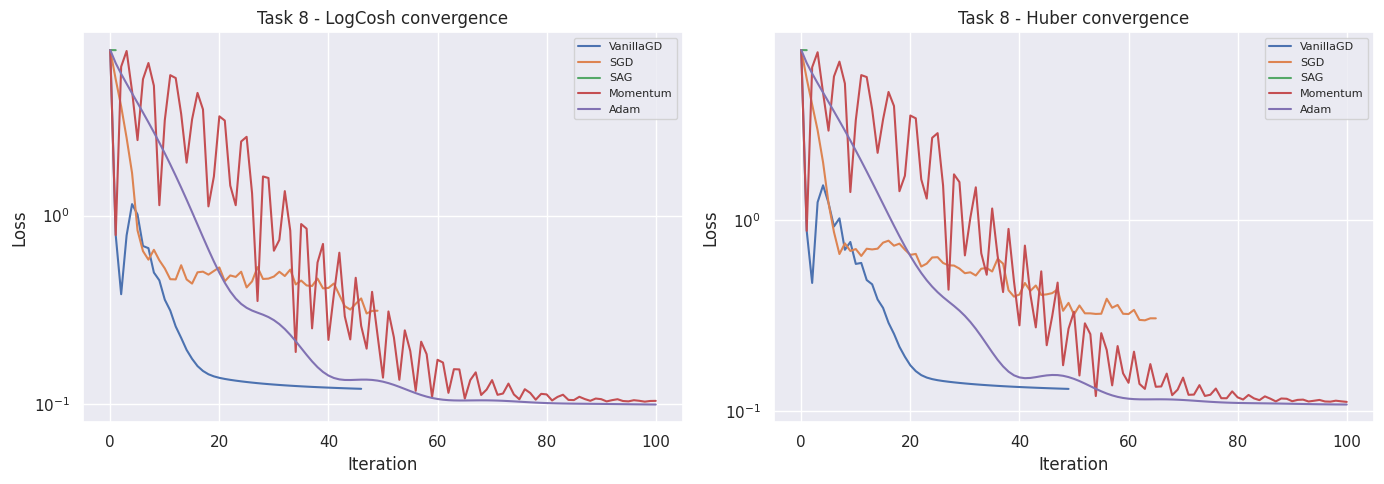

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, loss_name in enumerate(['LogCosh', 'Huber']):
    ax = axes[i]
    for name, result in all_loss_results[loss_name].items():
        ax.plot(result['model'].loss_history, label=name)
    ax.set_title(f'Task 8 - {loss_name} convergence')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.set_yscale('log')

plt.tight_layout()
plt.show()
